# Zbiorcza analiza skuteczności metod debiasingu CLIP

Notebook generuje wykresy porównawcze na podstawie wyników z wielu konceptów.

**Wymagania:** pliki `results_{CONCEPT}.csv` w katalogu `DATA_DIR` (domyślnie: bieżący katalog).  
Format każdego pliku: kolumny `target_attribute, bal_acc, auc, regime, debiased_concept, method, debias_layer, ba_raw, delta_ba, n_iterations, n_layers`.

**Generowane wykresy:**
1. Porównanie reżimów — mediana ΔBA na target konceptach  
2. Trade-off: skuteczność vs. szkody kolateralne  
3. Efektywność debiasingu per warstwa (heatmapa uśredniona po konceptach)  
4. Profil szkód kolateralnych per reżim  
5. Ranking metod CAV  
6. Pareto front — 1-BA konceptu vs. BA ogólne (oraz wersja AUC)

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
DATA_DIR = Path('.')          # Directory with results_{CONCEPT}.csv files
OUT_DIR  = Path('summary_plots')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ΔBA threshold considered as significant collateral damage/improvement
COLLATERAL_THRESHOLD = 0.02

# CAV methods palette
METHOD_COLORS = {
    'diff_means': '#4C78A8',
    'lr':         '#F58518',
    'pclarc':     '#54A24B',
    'none':       '#AAAAAA',
}

# Regimes palette and labels
REGIME_COLORS = {
    'raw':                  '#888888',
    'single':               '#4C78A8',
    'sequential':           '#F58518',
    'iterative':            '#E45756',
    'fixed_multi':          '#72B7B2',
    'iterative_all_layers': '#54A24B',
}

REGIME_LABELS = {
    'raw':                  'Raw baseline',
    'single':               'Single layer',
    'sequential':           'Sequential (24L)',
    'iterative':            'Iterative (single layer)',
    'fixed_multi':          'Fixed multi-layer',
    'iterative_all_layers': 'Iterative all-layers',
}

REGIME_MARKERS = {
    'single':               'o',
    'sequential':           's',
    'iterative':            '^',
    'fixed_multi':          'D',
    'iterative_all_layers': 'P',
}

In [3]:
# ── DATA LOADING ──────────────────────────────────────────────────────────────
dfs = []
for path in sorted(DATA_DIR.glob('results_*.csv')):
    concept = path.stem.replace('results_', '')
    df_tmp = pd.read_csv(path)
    df_tmp['concept_file'] = concept
    dfs.append(df_tmp)
    print(f'  Loaded {path.name}  →  {len(df_tmp)} rows')

assert dfs, f'No results_*.csv files found in {DATA_DIR.resolve()}'

df = pd.concat(dfs, ignore_index=True)

# Fill debiased_concept column from filename if missing
mask_none = df['debiased_concept'] == 'none'
df.loc[mask_none, 'debiased_concept'] = df.loc[mask_none, 'concept_file']

CONCEPTS = sorted(df['concept_file'].unique())
print(f'\nConcepts ({len(CONCEPTS)}): {CONCEPTS}')
print(f'Total rows: {len(df)}')
print(f'Regimes: {sorted(df["regime"].unique())}')
print(f'Methods: {sorted(df["method"].unique())}')

  Loaded results_bald.csv  →  5160 rows
  Loaded results_chubby.csv  →  5160 rows
  Loaded results_eyeglasses.csv  →  5160 rows
  Loaded results_male.csv  →  5160 rows
  Loaded results_wearing_hat.csv  →  5160 rows

Concepts (5): ['bald', 'chubby', 'eyeglasses', 'male', 'wearing_hat']
Total rows: 25800
Regimes: ['fixed_multi', 'iterative', 'iterative_all_layers', 'raw', 'sequential', 'single']
Methods: ['diff_means', 'lr', 'none', 'pclarc']


In [4]:
# ── HELPER FUNCTIONS ──────────────────────────────────────────────────────────

def get_debiased_rows(df):
    """Rows with actual debiasing (not raw)."""
    return df[(df['regime'] != 'raw') & df['delta_ba'].notna()].copy()


def best_config_per_regime_method_concept(df_deb):
    """
    For each (concept_file, regime, method): selects the configuration
    (debias_layer / n_iterations / n_layers) yielding the lowest delta_ba
    ON THE TARGET CONCEPT.
    Returns a DataFrame with all attributes for these configurations.
    """
    # Extract ΔBA on the target concept per configuration
    target_rows = df_deb[df_deb['target_attribute'] == df_deb['concept_file']].copy()

    config_cols = ['concept_file', 'regime', 'method', 'debias_layer', 'n_iterations', 'n_layers']

    best_idx = (
        target_rows
        .groupby(config_cols, dropna=False)['delta_ba']
        .mean()
        .reset_index()
        .sort_values('delta_ba')
        .drop_duplicates(subset=['concept_file', 'regime', 'method'], keep='first')
    )

    # Join full data (all attributes) for the selected configurations
    merged = best_idx.merge(
        df_deb,
        on=config_cols,
        how='left',
        suffixes=('_best', ''),
    )
    return merged


def pareto_front(points, minimize_x=True, minimize_y=False):
    """
    Computes the Pareto front (minimize X, maximize Y).
    Returns a boolean mask.
    """
    pts = np.array(points)
    n = len(pts)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        # Point i is dominated if there exists j with a better X and >= Y (or equal)
        dominated = (
            (pts[:, 0] <= pts[i, 0]) &
            (pts[:, 1] >= pts[i, 1]) &
            ((pts[:, 0] < pts[i, 0]) | (pts[:, 1] > pts[i, 1]))
        )
        dominated[i] = False
        if dominated.any():
            is_pareto[i] = False
    return is_pareto


df_deb = get_debiased_rows(df)
print(f'Rows with debiasing: {len(df_deb)}')

Rows with debiasing: 25600


## Wykres 1 — Porównanie reżimów: mediana ΔBA na target konceptach

Dla każdego reżimu i metody CAV: mediana (+ IQR) zmiany balanced accuracy
na target koncepte, uśredniona po wszystkich konceptach.  
Używamy **najlepszej konfiguracji** (optymalnej warstwy / liczby iteracji) per reżim.
Im bardziej ujemne, tym skuteczniejszy debiasing.

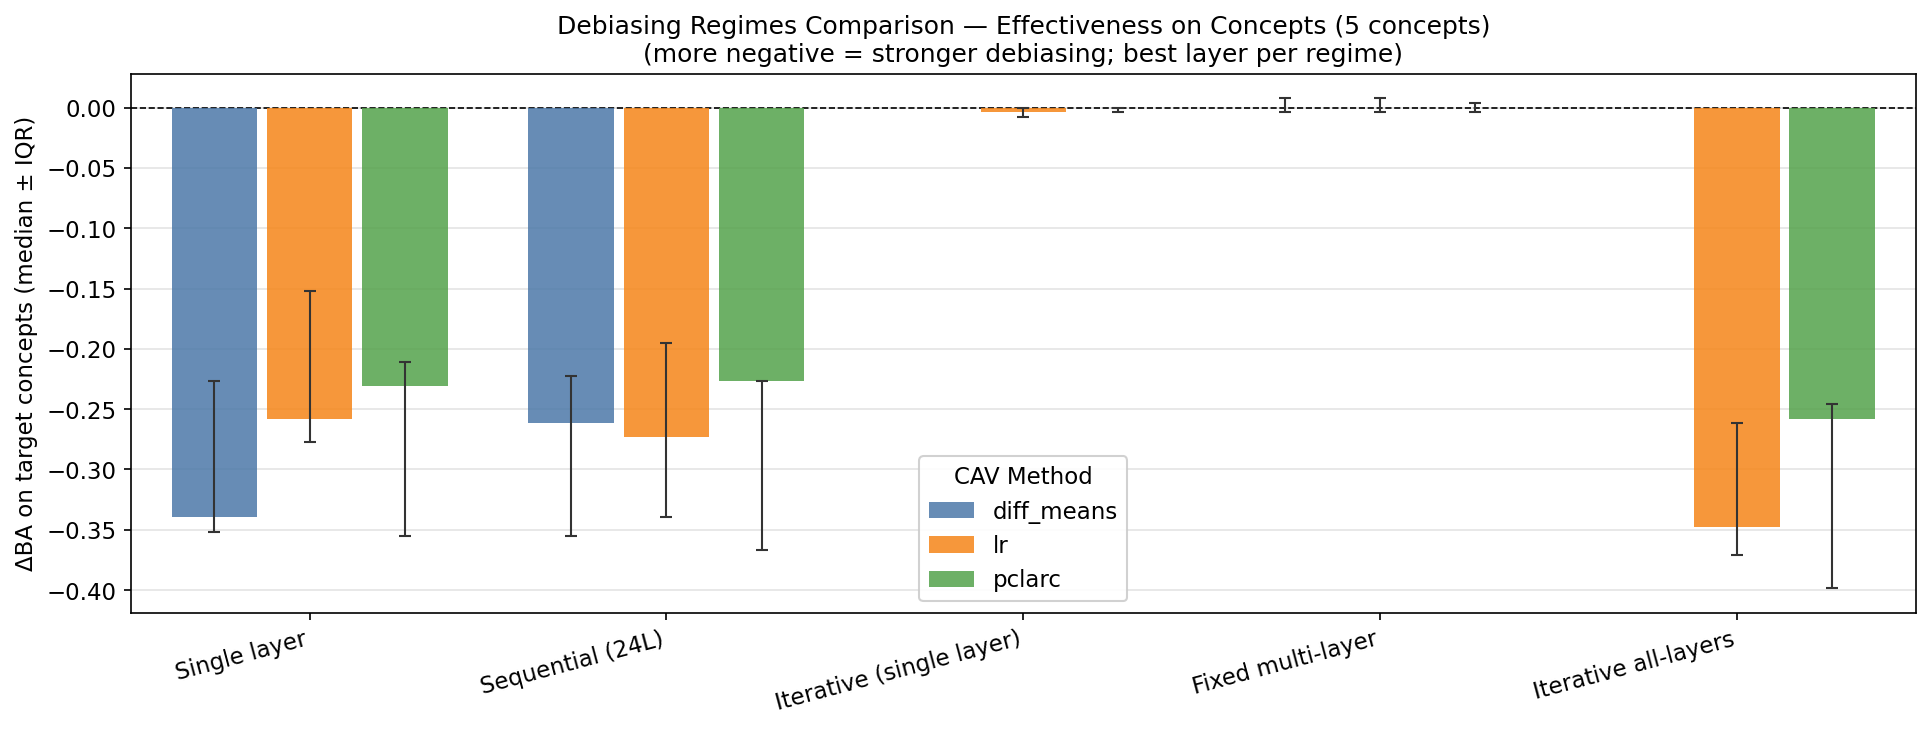

In [5]:
best = best_config_per_regime_method_concept(df_deb)

# Only rows with target concept
target_only = best[best['target_attribute'] == best['concept_file']]

regimes_order = ['single', 'sequential', 'iterative', 'fixed_multi', 'iterative_all_layers']
methods_order = ['diff_means', 'lr', 'pclarc']

fig, ax = plt.subplots(figsize=(13, 5))

n_regimes = len(regimes_order)
n_methods = len(methods_order)
group_w = 0.8
bar_w = group_w / n_methods
x = np.arange(n_regimes)

for mi, method in enumerate(methods_order):
    offset = (mi - (n_methods - 1) / 2) * bar_w
    vals, q25s, q75s = [], [], []
    for regime in regimes_order:
        sub = target_only[(target_only['regime'] == regime) & (target_only['method'] == method)]['delta_ba']
        if len(sub) == 0:
            vals.append(np.nan)
            q25s.append(0)
            q75s.append(0)
        else:
            med = sub.median()
            vals.append(med)
            q25s.append(med - sub.quantile(0.25))
            q75s.append(sub.quantile(0.75) - med)
            
    bars = ax.bar(
        x + offset, vals, bar_w * 0.9,
        color=METHOD_COLORS[method], alpha=0.85,
        label=method, zorder=3,
    )
    ax.errorbar(
        x + offset, vals,
        yerr=[q25s, q75s],
        fmt='none', color='#333333', capsize=3, linewidth=1, zorder=4,
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=2)
ax.set_xticks(x)
ax.set_xticklabels([REGIME_LABELS[r] for r in regimes_order], rotation=15, ha='right')
ax.set_ylabel('ΔBA on target concepts (median ± IQR)')
ax.set_title(
    f'Debiasing Regimes Comparison — Effectiveness on Concepts ({len(CONCEPTS)} concepts)\n'
    '(more negative = stronger debiasing; best layer per regime)'
)
ax.legend(title='CAV Method', framealpha=0.9)
ax.set_xlim(-0.5, n_regimes - 0.5)
ax.grid(axis='y', alpha=0.35, zorder=1)
plt.tight_layout()
plt.savefig(OUT_DIR / '01_regime_comparison.png', dpi=150)
plt.show()

## Wykres 2 — Trade-off: skuteczność debiasingu vs. szkody kolateralne

Każdy punkt to jedna konfiguracja (reżim × metoda × najlepsza warstwa, uśrednione po konceptach).  
- Oś X: mediana ΔBA na target konceptach (im bardziej ujemne = lepszy debiasing)  
- Oś Y: mediana ΔBA na **pozostałych** atrybutach (im bliżej 0 = mniej szkód kolateralnych)  

Idealny punkt leży w lewym górnym rogu.

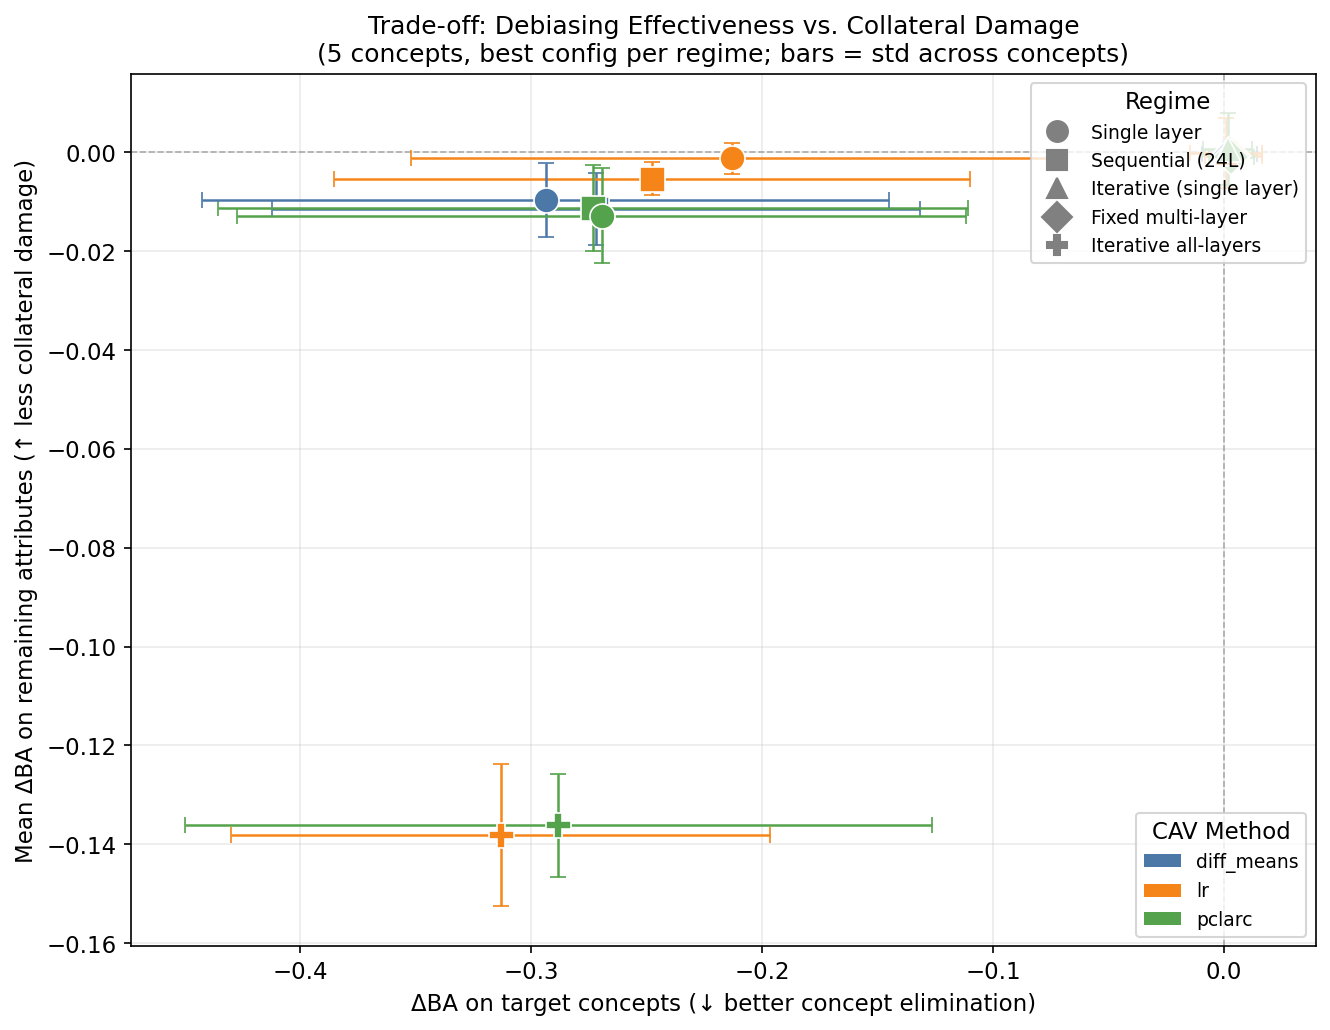

In [6]:
# Aggregation: per (regime, method, concept_file) — target ΔBA vs. collateral ΔBA
target_mask = best['target_attribute'] == best['concept_file']
collateral_mask = ~target_mask & best['delta_ba'].notna()

target_agg = (
    best[target_mask]
    .groupby(['regime', 'method', 'concept_file'])['delta_ba']
    .mean()
    .rename('delta_ba_target')
)
collateral_agg = (
    best[collateral_mask]
    .groupby(['regime', 'method', 'concept_file'])['delta_ba']
    .mean()
    .rename('delta_ba_collateral')
)
tradeoff = pd.concat([target_agg, collateral_agg], axis=1).reset_index()

# Average across concepts
tradeoff_mean = tradeoff.groupby(['regime', 'method'])[['delta_ba_target', 'delta_ba_collateral']].mean().reset_index()
tradeoff_std  = tradeoff.groupby(['regime', 'method'])[['delta_ba_target', 'delta_ba_collateral']].std().reset_index()

fig, ax = plt.subplots(figsize=(9, 7))

for _, row in tradeoff_mean.iterrows():
    regime, method = row['regime'], row['method']
    if method not in METHOD_COLORS or regime not in REGIME_MARKERS:
        continue
    std_row = tradeoff_std[(tradeoff_std['regime'] == regime) & (tradeoff_std['method'] == method)].iloc[0]

    ax.errorbar(
        row['delta_ba_target'], row['delta_ba_collateral'],
        xerr=std_row['delta_ba_target'], yerr=std_row['delta_ba_collateral'],
        fmt=REGIME_MARKERS[regime], color=METHOD_COLORS[method],
        markersize=12, capsize=4, linewidth=1.2,
        markeredgecolor='white', markeredgewidth=0.8,
        zorder=4,
    )

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('ΔBA on target concepts (↓ better concept elimination)')
ax.set_ylabel('Mean ΔBA on remaining attributes (↑ less collateral damage)')
ax.set_title(
    f'Trade-off: Debiasing Effectiveness vs. Collateral Damage\n'
    f'({len(CONCEPTS)} concepts, best config per regime; bars = std across concepts)'
)

# Shape legend (regimes)
regime_handles = [
    Line2D([0], [0], marker=REGIME_MARKERS[r], color='gray', linestyle='None',
           markersize=10, label=REGIME_LABELS[r])
    for r in regimes_order if r in REGIME_MARKERS
]
# Color legend (methods)
method_handles = [
    mpatches.Patch(facecolor=METHOD_COLORS[m], label=m)
    for m in methods_order
]
leg1 = ax.legend(handles=regime_handles, title='Regime', loc='upper right', fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=method_handles, title='CAV Method', loc='lower right', fontsize=9)

ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / '02_tradeoff_effectiveness_vs_collateral.png', dpi=150)
plt.show()

## Wykres 3 — Efektywność debiasingu per warstwa (heatmapa)

Mediana ΔBA na target konceptach, uśredniona po konceptach,  
jako funkcja warstwy debiasingu — osobno per reżim i metoda CAV.  
(Dla reżimów bez parametru warstwy: stała linia.)

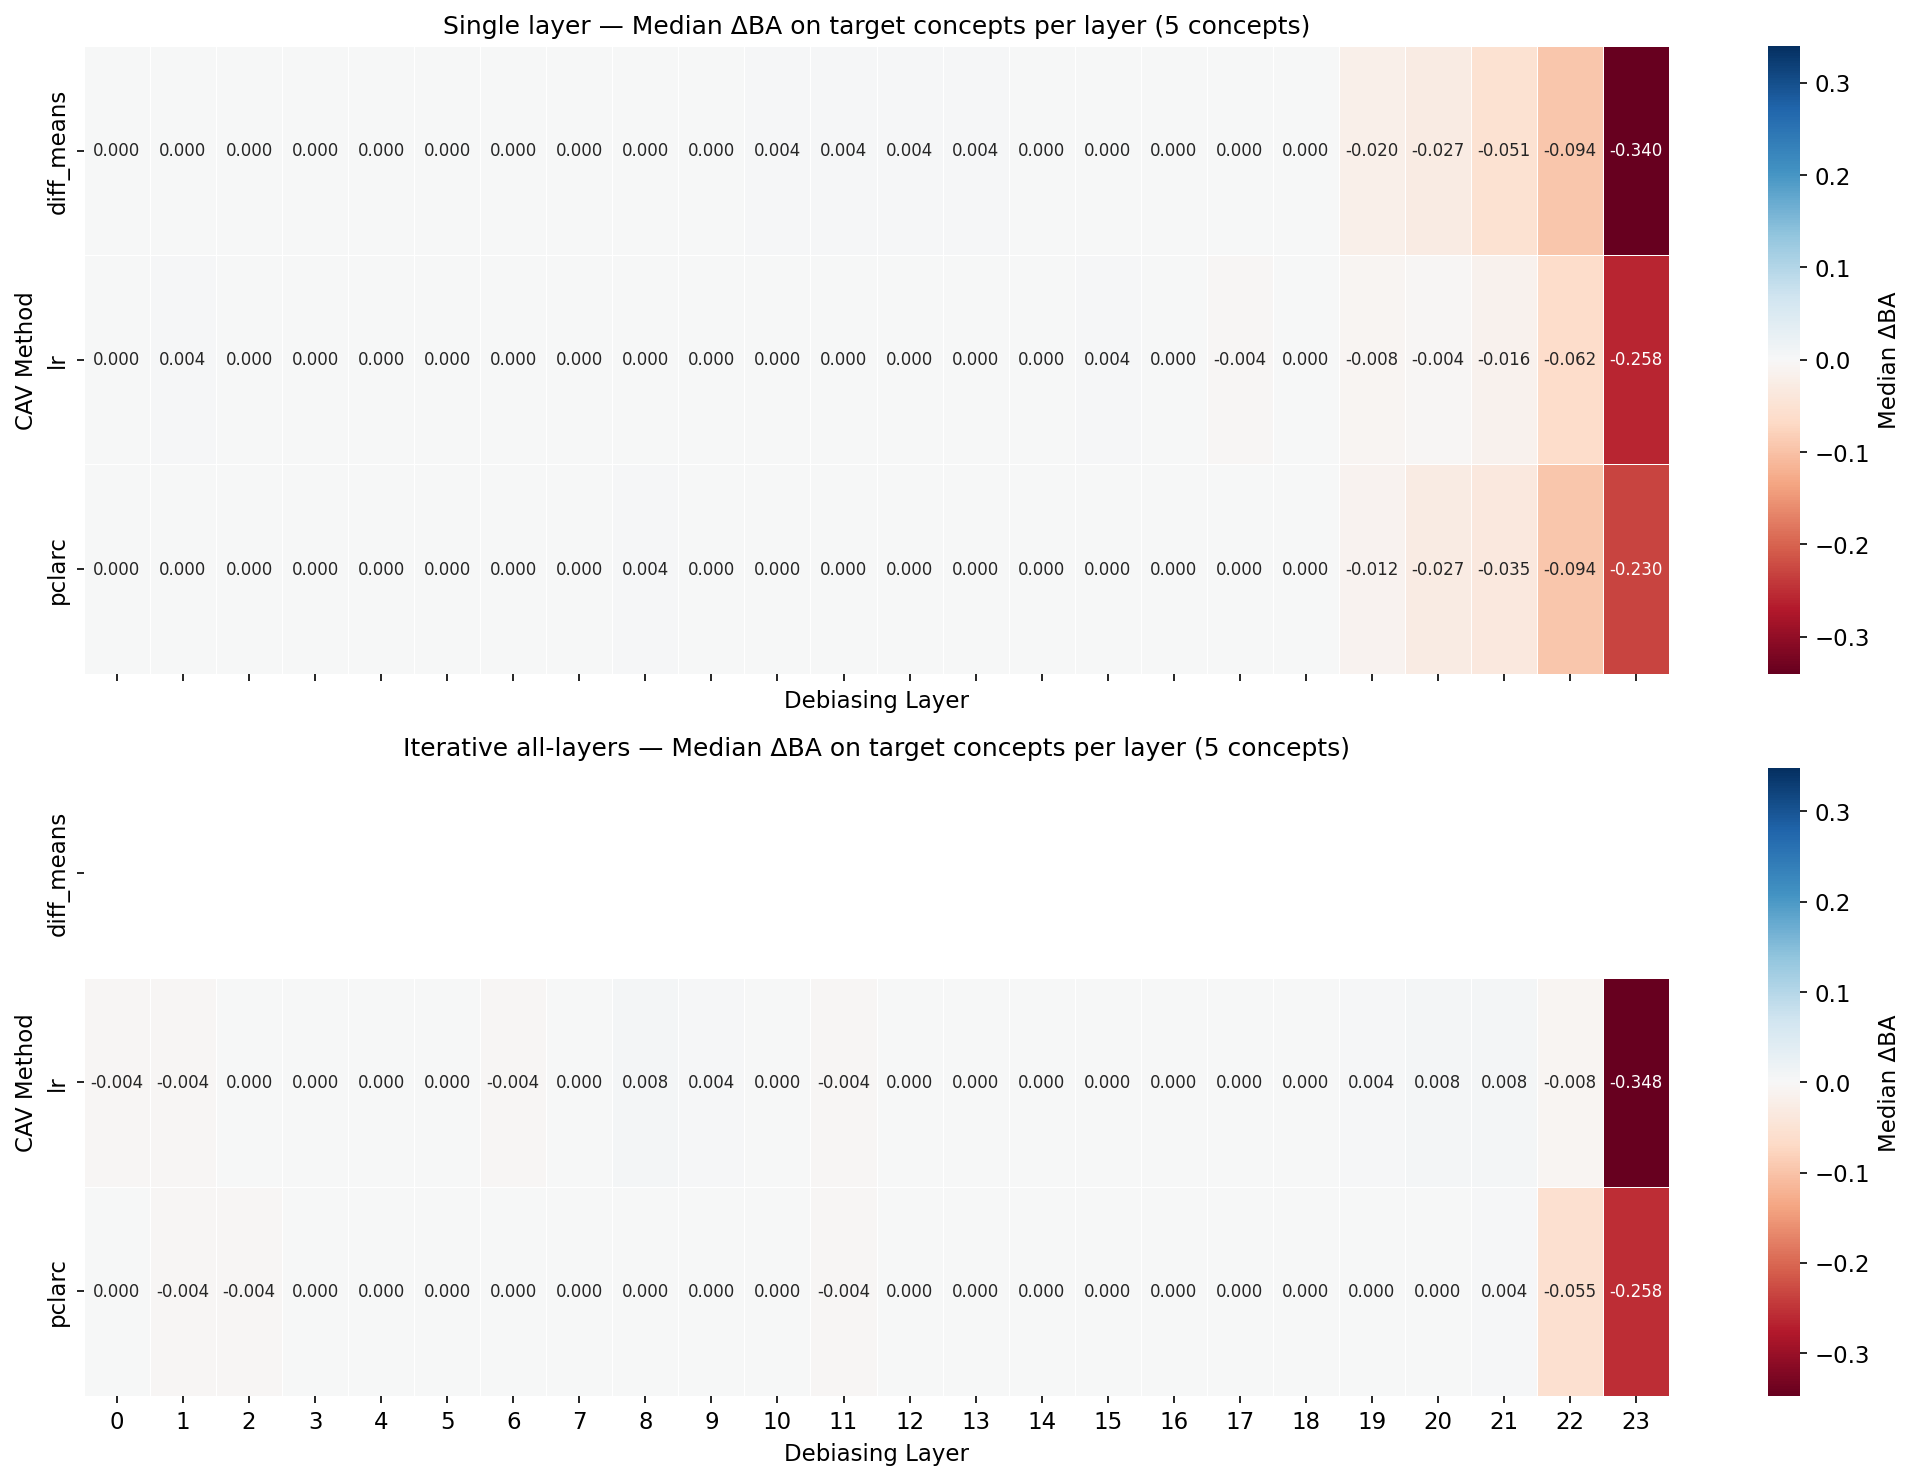

In [7]:
# Only regimes with a layer parameter: single, iterative_all_layers
layer_regimes = ['single', 'iterative_all_layers']
layer_methods = ['diff_means', 'lr', 'pclarc']

fig, axes = plt.subplots(len(layer_regimes), 1, figsize=(14, 5 * len(layer_regimes)), sharex=True)
if len(layer_regimes) == 1:
    axes = [axes]

for ax, regime in zip(axes, layer_regimes):
    sub = df_deb[df_deb['regime'] == regime]
    
    # Vectorized target filtering instead of apply(lambda)
    target_sub = sub[sub['target_attribute'] == sub['concept_file']]

    pivot_data = {}
    for method in layer_methods:
        grp = (
            target_sub[target_sub['method'] == method]
            .groupby(['concept_file', 'debias_layer'])['delta_ba']
            .mean()
            .reset_index()
            .groupby('debias_layer')['delta_ba']
            .median()
        )
        pivot_data[method] = grp

    pivot = pd.DataFrame(pivot_data).T  # rows=methods, cols=layers
    pivot.columns = [int(c) for c in pivot.columns]
    pivot = pivot[sorted(pivot.columns)]

    # Safe vmax calculation to prevent ValueError on empty slices or all-NaNs
    finite_vals = pivot.values[np.isfinite(pivot.values)]
    vmax = max(abs(finite_vals).max(), 0.01) if len(finite_vals) > 0 else 0.01

    sns.heatmap(
        pivot, ax=ax, cmap='RdBu', center=0,
        vmin=-vmax, vmax=vmax,
        linewidths=0.4, linecolor='white',
        annot=True, fmt='.3f', annot_kws={'size': 8},
        cbar_kws={'label': 'Median ΔBA'},
    )
    
    ax.set_title(f'{REGIME_LABELS.get(regime, regime)} — Median ΔBA on target concepts per layer ({len(CONCEPTS)} concepts)')
    ax.set_xlabel('Debiasing Layer')
    ax.set_ylabel('CAV Method')

plt.tight_layout()
plt.savefig(OUT_DIR / '03_layer_effectiveness_heatmap.png', dpi=150)
plt.show()

## Wykres 4 — Profil szkód kolateralnych per reżim

Dla każdego reżimu i metody: liczba atrybutów z ΔBA < -threshold (szkody)
oraz ΔBA > +threshold (nieoczekiwane poprawy), uśredniona po konceptach.
Używamy najlepszej konfiguracji per reżim.

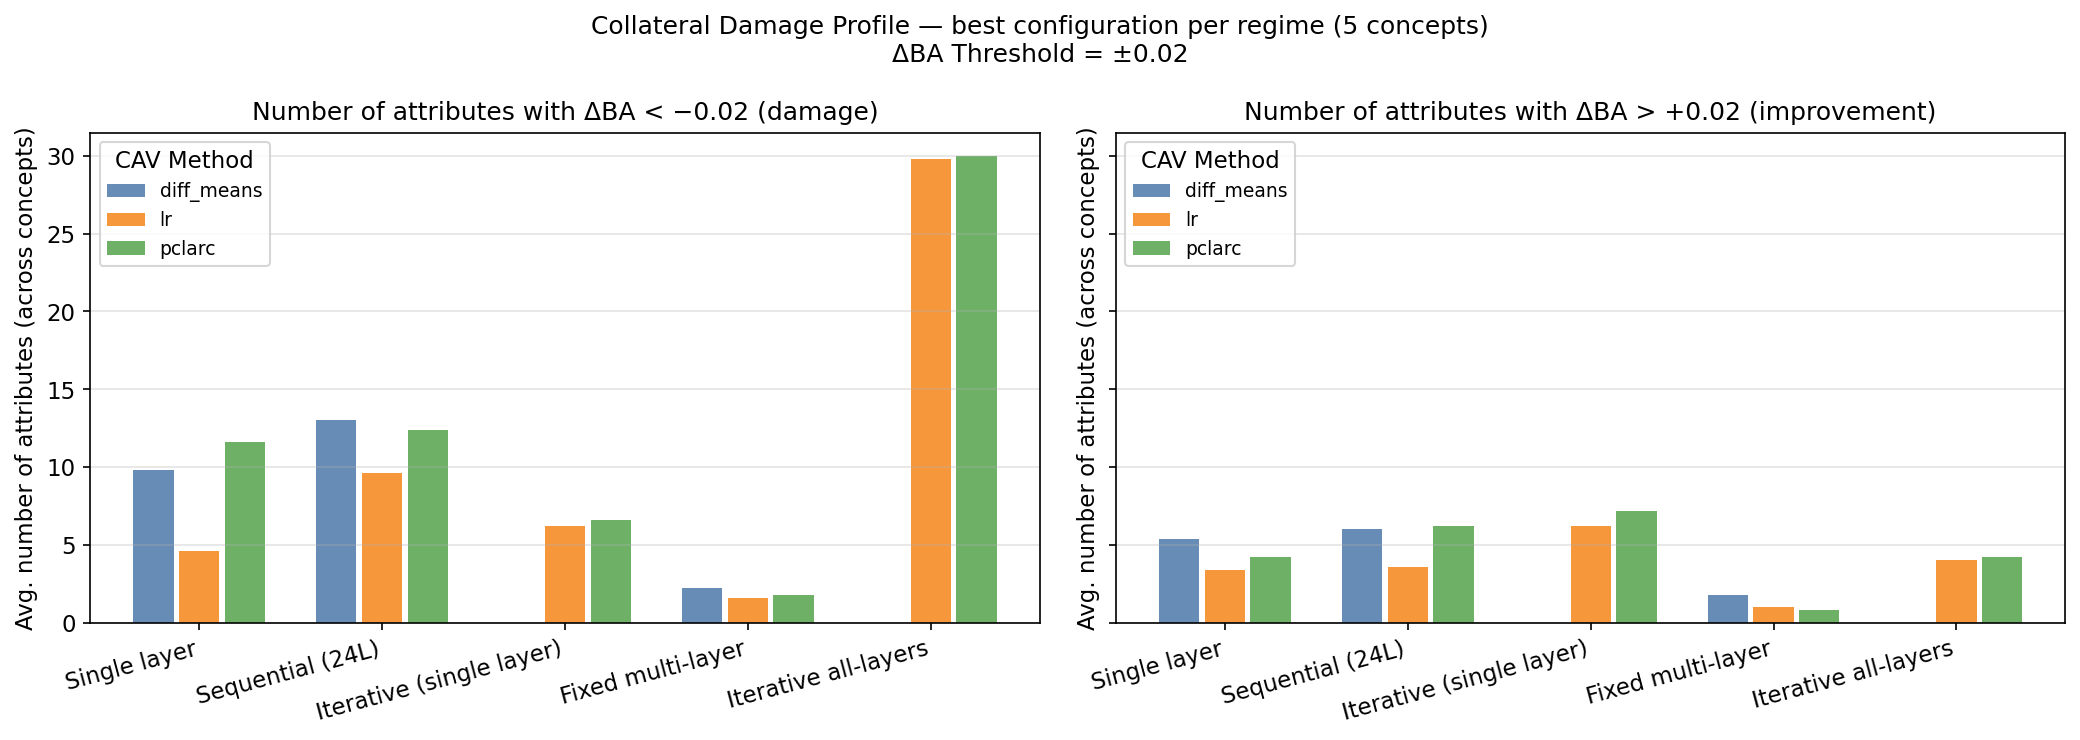

In [8]:
# Vectorized filtering instead of apply(lambda)
collateral_best = best[best['target_attribute'] != best['concept_file']]

records = []
for (regime, method, concept), grp in collateral_best.groupby(['regime', 'method', 'concept_file']):
    n_damaged  = (grp['delta_ba'] < -COLLATERAL_THRESHOLD).sum()
    n_improved = (grp['delta_ba'] >  COLLATERAL_THRESHOLD).sum()
    n_total    = grp['delta_ba'].notna().sum()
    records.append({
        'regime': regime, 'method': method, 'concept': concept,
        'n_damaged': n_damaged, 'n_improved': n_improved, 'n_total': n_total
    })
df_coll = pd.DataFrame(records)

coll_mean = df_coll.groupby(['regime', 'method'])[['n_damaged', 'n_improved']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, title, color_pos in zip(
    axes,
    ['n_damaged', 'n_improved'],
    [f'Number of attributes with ΔBA < −{COLLATERAL_THRESHOLD} (damage)',
     f'Number of attributes with ΔBA > +{COLLATERAL_THRESHOLD} (improvement)'],
    ['#E45756', '#54A24B'],
):
    pivot = coll_mean.pivot(index='regime', columns='method', values=col)
    pivot = pivot.reindex(index=[r for r in regimes_order if r in pivot.index],
                          columns=[m for m in methods_order if m in pivot.columns])
    x = np.arange(len(pivot))
    for mi, method in enumerate(pivot.columns):
        offset = (mi - (len(pivot.columns) - 1) / 2) * 0.25
        ax.bar(x + offset, pivot[method], 0.22,
               color=METHOD_COLORS[method], alpha=0.85, label=method)
    ax.set_xticks(x)
    ax.set_xticklabels([REGIME_LABELS.get(r, r) for r in pivot.index], rotation=15, ha='right')
    ax.set_title(title)
    ax.set_ylabel('Avg. number of attributes (across concepts)')
    ax.grid(axis='y', alpha=0.35)
    ax.legend(title='CAV Method', fontsize=9)

fig.suptitle(
    f'Collateral Damage Profile — best configuration per regime ({len(CONCEPTS)} concepts)\n'
    f'ΔBA Threshold = ±{COLLATERAL_THRESHOLD}',
    fontsize=12
)
plt.tight_layout()
plt.savefig(OUT_DIR / '04_collateral_damage_profile.png', dpi=150)
plt.show()

## Wykres 5 — Ranking metod CAV

Box plot ΔBA na target konceptach per metoda CAV — wszystkie reżimy łącznie, wszystkie koncepty.  
Pozwala ocenić, czy wybór metody CAV (diff_means / lr / pclarc) ma istotne znaczenie.

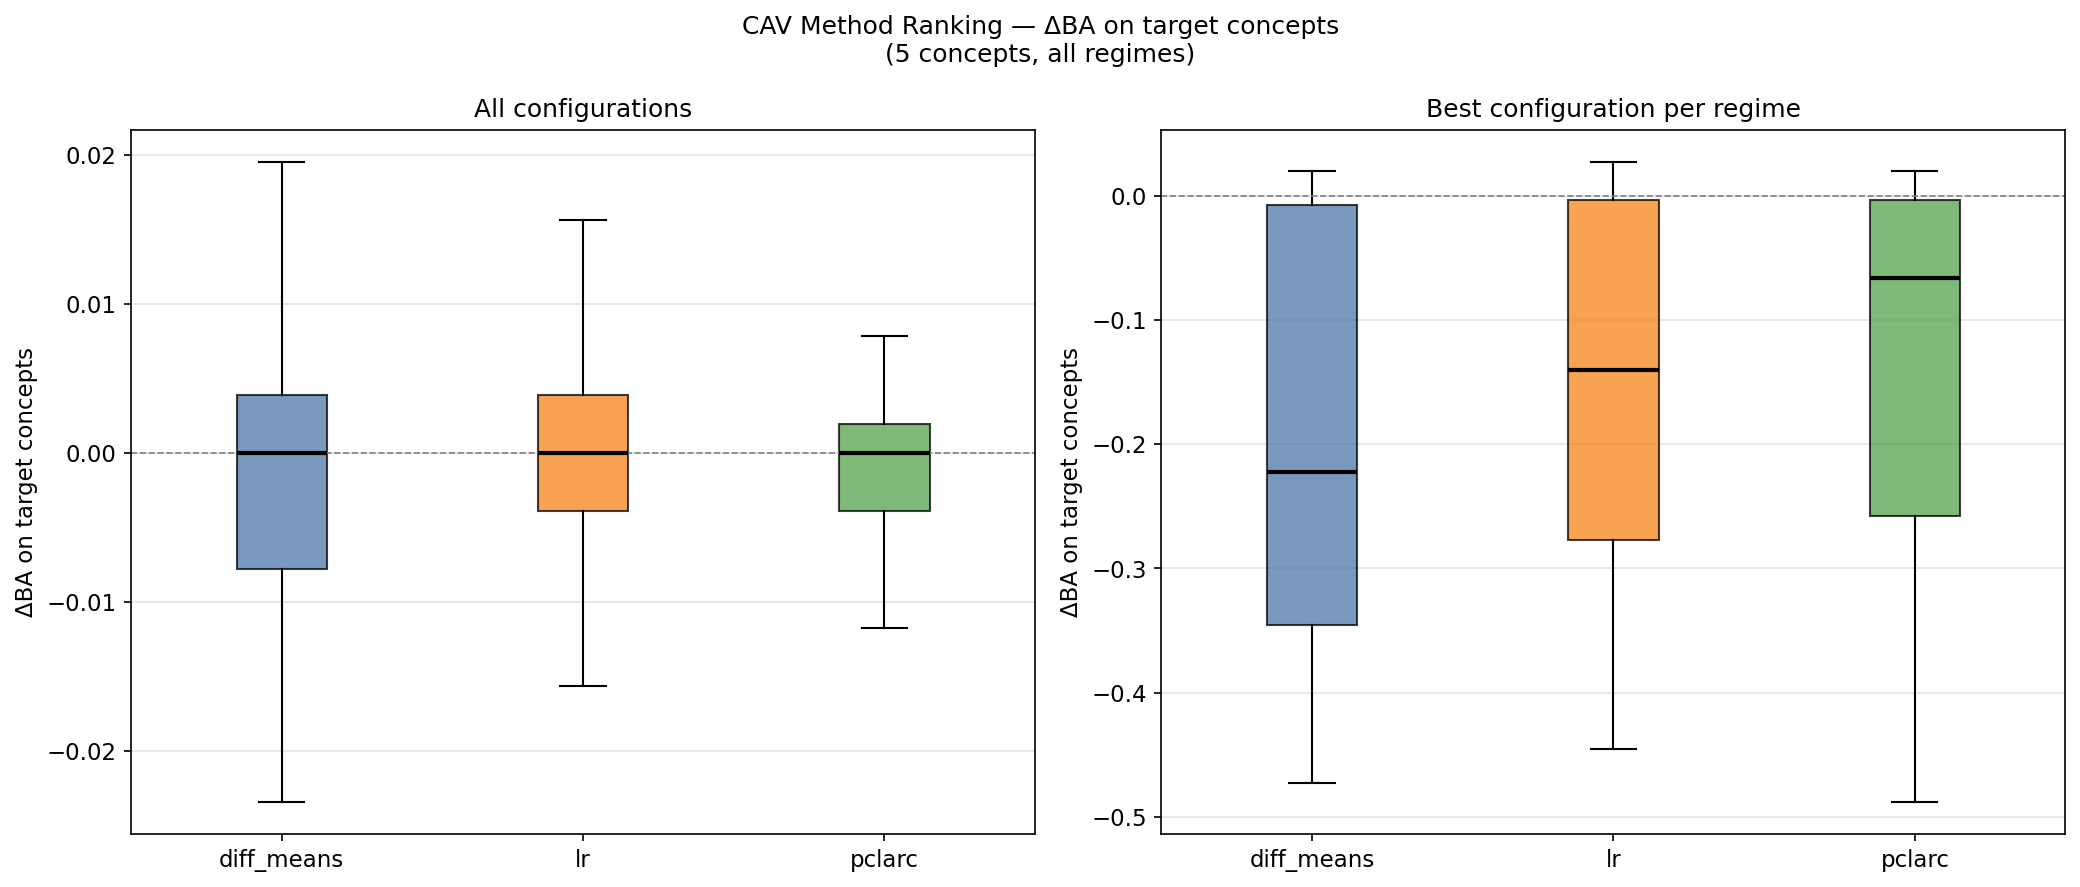

In [9]:
# Vectorized filtering instead of apply(lambda)
target_all = df_deb[df_deb['target_attribute'] == df_deb['concept_file']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A — all configurations
ax = axes[0]
data_by_method = [target_all[target_all['method'] == m]['delta_ba'].dropna() for m in methods_order]
bp = ax.boxplot(data_by_method, patch_artist=True, notch=False, showfliers=False,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, method in zip(bp['boxes'], methods_order):
    patch.set_facecolor(METHOD_COLORS[method])
    patch.set_alpha(0.75)
ax.set_xticks(range(1, len(methods_order) + 1))
ax.set_xticklabels(methods_order)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('ΔBA on target concepts')
ax.set_title('All configurations')
ax.grid(axis='y', alpha=0.35)

# Panel B — only best configuration per regime
ax = axes[1]
data_best = [target_only[target_only['method'] == m]['delta_ba'].dropna() for m in methods_order]
bp2 = ax.boxplot(data_best, patch_artist=True, notch=False, showfliers=False,
                 medianprops={'color': 'black', 'linewidth': 2})
for patch, method in zip(bp2['boxes'], methods_order):
    patch.set_facecolor(METHOD_COLORS[method])
    patch.set_alpha(0.75)
ax.set_xticks(range(1, len(methods_order) + 1))
ax.set_xticklabels(methods_order)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('ΔBA on target concepts')
ax.set_title('Best configuration per regime')
ax.grid(axis='y', alpha=0.35)

fig.suptitle(
    f'CAV Method Ranking — ΔBA on target concepts\n({len(CONCEPTS)} concepts, all regimes)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(OUT_DIR / '05_cav_method_ranking.png', dpi=150)
plt.show()

## Wykres 6 — Pareto front (Balanced Accuracy)

**Oś X:** `1 − BA` na target konceptach (uśrednione po konceptach) — im wyższe, tym GORSZE usunięcie konceptu  
→ chcemy jak najniższe X (efektywna eliminacja)

**Oś Y:** BA uśrednione po **wszystkich atrybutach** w pliku — im wyższe, tym lepiej zachowana jakość ogólna modelu

Każdy punkt to jedna konfiguracja (reżim × metoda × warstwa/iter).  
Linia Pareto frontu zaznacza konfiguracje **niezdominowane** (chcemy lewego górnego rogu).

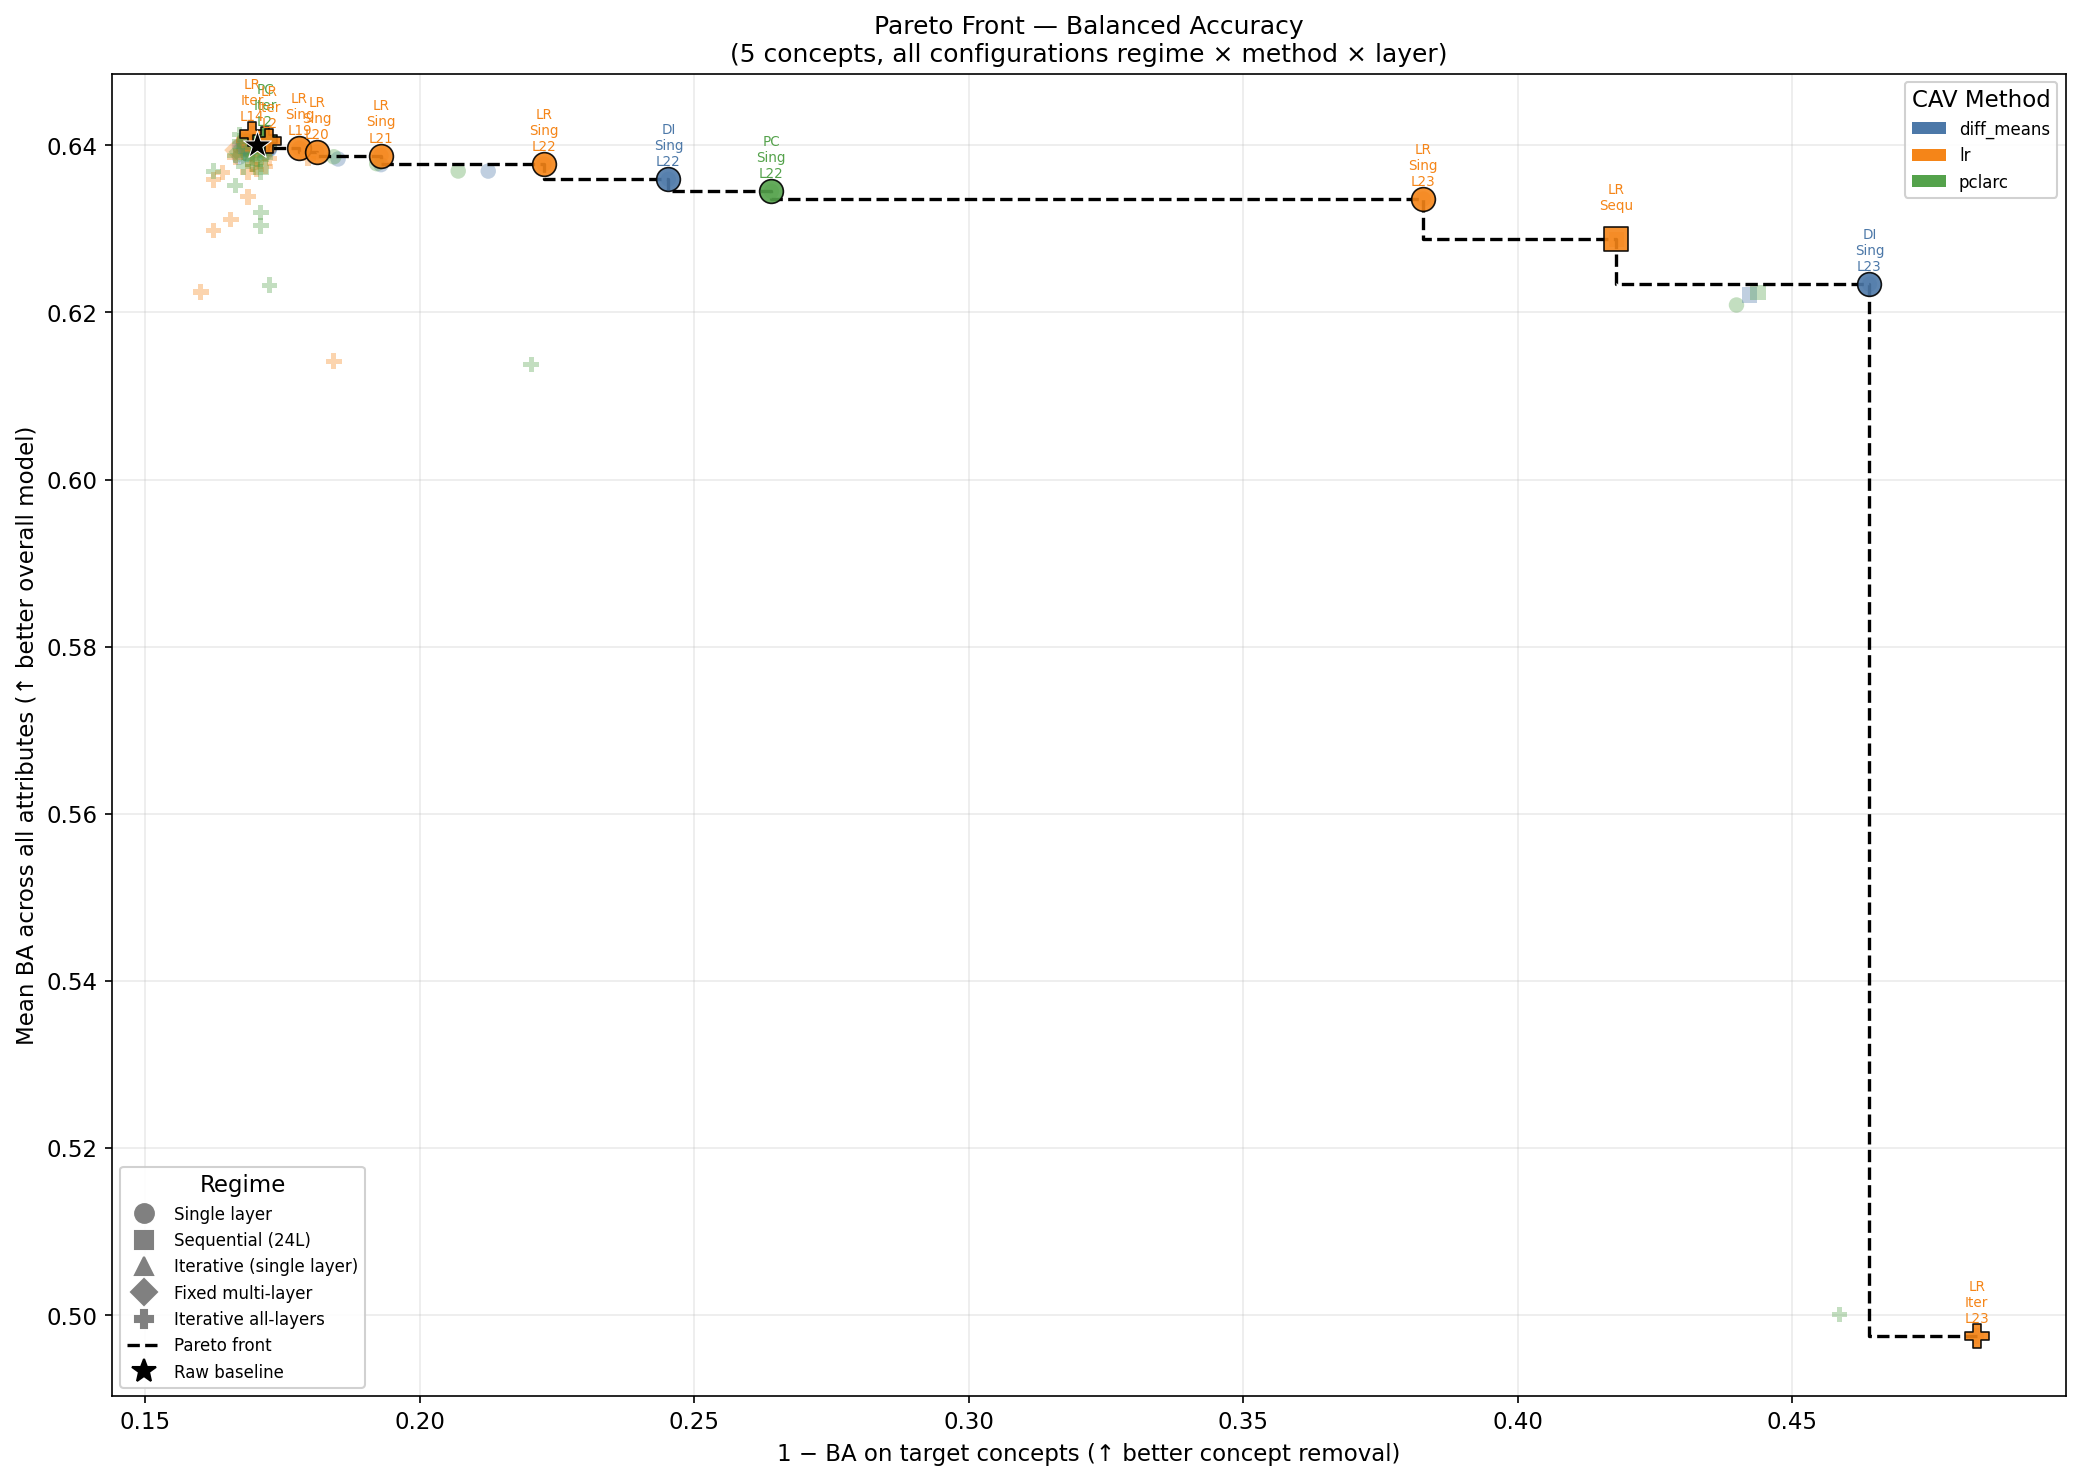

In [10]:
# ── HELPER: PARETO FRONT (MAX-MAX) ────────────────────────────────────────────

def pareto_front(points, minimize_x=False, minimize_y=False):
    """
    Wyznacza front Pareto. Domyślnie skonfigurowany na Max-Max
    (szuka punktów niedominowanych w kierunku prawego górnego rogu).
    """
    pts = np.array(points)
    n = len(pts)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        
        better_x = (pts[:, 0] <= pts[i, 0]) if minimize_x else (pts[:, 0] >= pts[i, 0])
        strict_x = (pts[:, 0] < pts[i, 0])  if minimize_x else (pts[:, 0] > pts[i, 0])
        
        better_y = (pts[:, 1] <= pts[i, 1]) if minimize_y else (pts[:, 1] >= pts[i, 1])
        strict_y = (pts[:, 1] < pts[i, 1])  if minimize_y else (pts[:, 1] > pts[i, 1])
        
        dominated = better_x & better_y & (strict_x | strict_y)
        dominated[i] = False
        
        if dominated.any():
            is_pareto[i] = False
    return is_pareto


def compute_pareto_data(df_deb, metric_col='bal_acc'):
    """
    For each configuration (regime, method, debias_layer, n_iterations, n_layers):
      - X = 1 - mean(metric_col on target concepts across concepts)
      - Y = mean(metric_col on ALL attributes across concepts)
    """
    config_cols = ['regime', 'method', 'debias_layer', 'n_iterations', 'n_layers']

    # Mark if the row is a target concept
    df_deb = df_deb.copy()
    # Vectorized check instead of apply
    df_deb['is_target'] = df_deb['target_attribute'] == df_deb['concept_file']

    # Per (config, concept_file): average metric on target and on all
    target_per_concept = (
        df_deb[df_deb['is_target']]
        .groupby(config_cols + ['concept_file'], dropna=False)[metric_col]
        .mean()
        .reset_index()
        .rename(columns={metric_col: 'metric_target'})
    )
    all_per_concept = (
        df_deb
        .groupby(config_cols + ['concept_file'], dropna=False)[metric_col]
        .mean()
        .reset_index()
        .rename(columns={metric_col: 'metric_all'})
    )
    merged = target_per_concept.merge(all_per_concept, on=config_cols + ['concept_file'])

    # Average across concepts
    agg = merged.groupby(config_cols, dropna=False)[['metric_target', 'metric_all']].mean().reset_index()
    agg['x'] = 1 - agg['metric_target']   # 1 - BA_target (higher = better debiasing)
    agg['y'] = agg['metric_all']          # BA_all (higher = better overall model)
    return agg


def plot_pareto(agg, metric_name, ax, raw_point=None):
    """Plots the Pareto front on the given axis."""
    for regime in regimes_order:
        for method in methods_order:
            sub = agg[(agg['regime'] == regime) & (agg['method'] == method)]
            if sub.empty:
                continue
            ax.scatter(
                sub['x'], sub['y'],
                c=METHOD_COLORS[method],
                marker=REGIME_MARKERS.get(regime, 'o'),
                s=55, alpha=0.35, zorder=3,
                edgecolors='none',
            )

    # Pareto front (wymuszamy maksymalizację osi X i Y)
    pts = agg[['x', 'y']].values
    is_pf = pareto_front(pts, minimize_x=False, minimize_y=False)
    pf_pts = agg[is_pf].sort_values('x')

    # Zmiana 'where' na 'pre' rysuje prawidłowe schodki od góry dla układu Max-Max
    ax.step(
        pf_pts['x'].values, pf_pts['y'].values,
        where='pre', color='black', linewidth=1.6, zorder=5,
        label='Pareto front', linestyle='--',
    )

    # Pareto front point labels
    for _, row in pf_pts.iterrows():
        regime, method = row['regime'], row['method']
        layer_info = ''
        if not np.isnan(row.get('debias_layer', float('nan'))) and row['debias_layer'] >= 0:
            layer_info = f"L{int(row['debias_layer'])}"
        label = f"{method[:2].upper()}\n{REGIME_LABELS.get(regime,'')[:4]}\n{layer_info}"
        ax.annotate(
            label, (row['x'], row['y']),
            fontsize=6.5, ha='center', va='bottom',
            xytext=(0, 5), textcoords='offset points',
            color=METHOD_COLORS.get(method, 'black'),
            zorder=6,
        )
        ax.scatter(row['x'], row['y'],
                   c=METHOD_COLORS.get(method, 'black'),
                   marker=REGIME_MARKERS.get(regime, 'o'),
                   s=130, alpha=0.9, zorder=6, edgecolors='black', linewidths=0.8)

    # Raw baseline
    if raw_point is not None:
        ax.scatter(*raw_point, color='black', marker='*', s=200, zorder=7,
                   label='Raw baseline', edgecolors='white', linewidths=0.5)

    # Poprawiona strzałka: (↑ better concept removal)
    ax.set_xlabel(f'1 − {metric_name} on target concepts (↑ better concept removal)')
    ax.set_ylabel(f'Mean {metric_name} across all attributes (↑ better overall model)')
    ax.grid(alpha=0.25)

    # Legends
    regime_handles = [
        Line2D([0], [0], marker=REGIME_MARKERS[r], color='gray', linestyle='None',
               markersize=9, label=REGIME_LABELS.get(r, r))
        for r in regimes_order if r in REGIME_MARKERS
    ]
    method_handles = [
        mpatches.Patch(facecolor=METHOD_COLORS[m], label=m)
        for m in methods_order
    ]
    pareto_handle = Line2D([0], [0], color='black', linestyle='--', linewidth=1.6, label='Pareto front')
    raw_handle = Line2D([0], [0], marker='*', color='black', linestyle='None', markersize=12, label='Raw baseline')

    leg1 = ax.legend(handles=regime_handles + [pareto_handle, raw_handle],
                     title='Regime', loc='lower left', fontsize=8, framealpha=0.9)
    ax.add_artist(leg1)
    ax.legend(handles=method_handles, title='CAV Method', loc='upper right', fontsize=8, framealpha=0.9)


# Calculate raw baseline
raw_rows = df[df['regime'] == 'raw']

def get_raw_point(metric_col):
    """Raw: X = 1-BA on concepts, Y = mean BA across all attributes."""
    target_metric = []
    all_metric = []
    for concept in CONCEPTS:
        sub = raw_rows[raw_rows['concept_file'] == concept]
        tgt = sub[sub['target_attribute'] == concept][metric_col]
        if len(tgt):
            target_metric.append(tgt.mean())
        all_metric.append(sub[metric_col].mean())
    return 1 - np.mean(target_metric), np.mean(all_metric)

# ── PARETO BA ────────────────────────────────────────────────────────────────
agg_ba = compute_pareto_data(df_deb, 'bal_acc')
raw_ba = get_raw_point('bal_acc')

fig, ax = plt.subplots(figsize=(14, 10))
plot_pareto(agg_ba, 'BA', ax, raw_point=raw_ba)
ax.set_title(
    f'Pareto Front — Balanced Accuracy\n'
    f'({len(CONCEPTS)} concepts, all configurations regime × method × layer)'
)
plt.tight_layout()
plt.savefig(OUT_DIR / '06a_pareto_ba.png', dpi=150)
plt.show()

## Wykres 6b — Pareto front (AUC-ROC)

Identyczna logika jak wykres 6, ale metryka to **AUC-ROC** zamiast Balanced Accuracy.

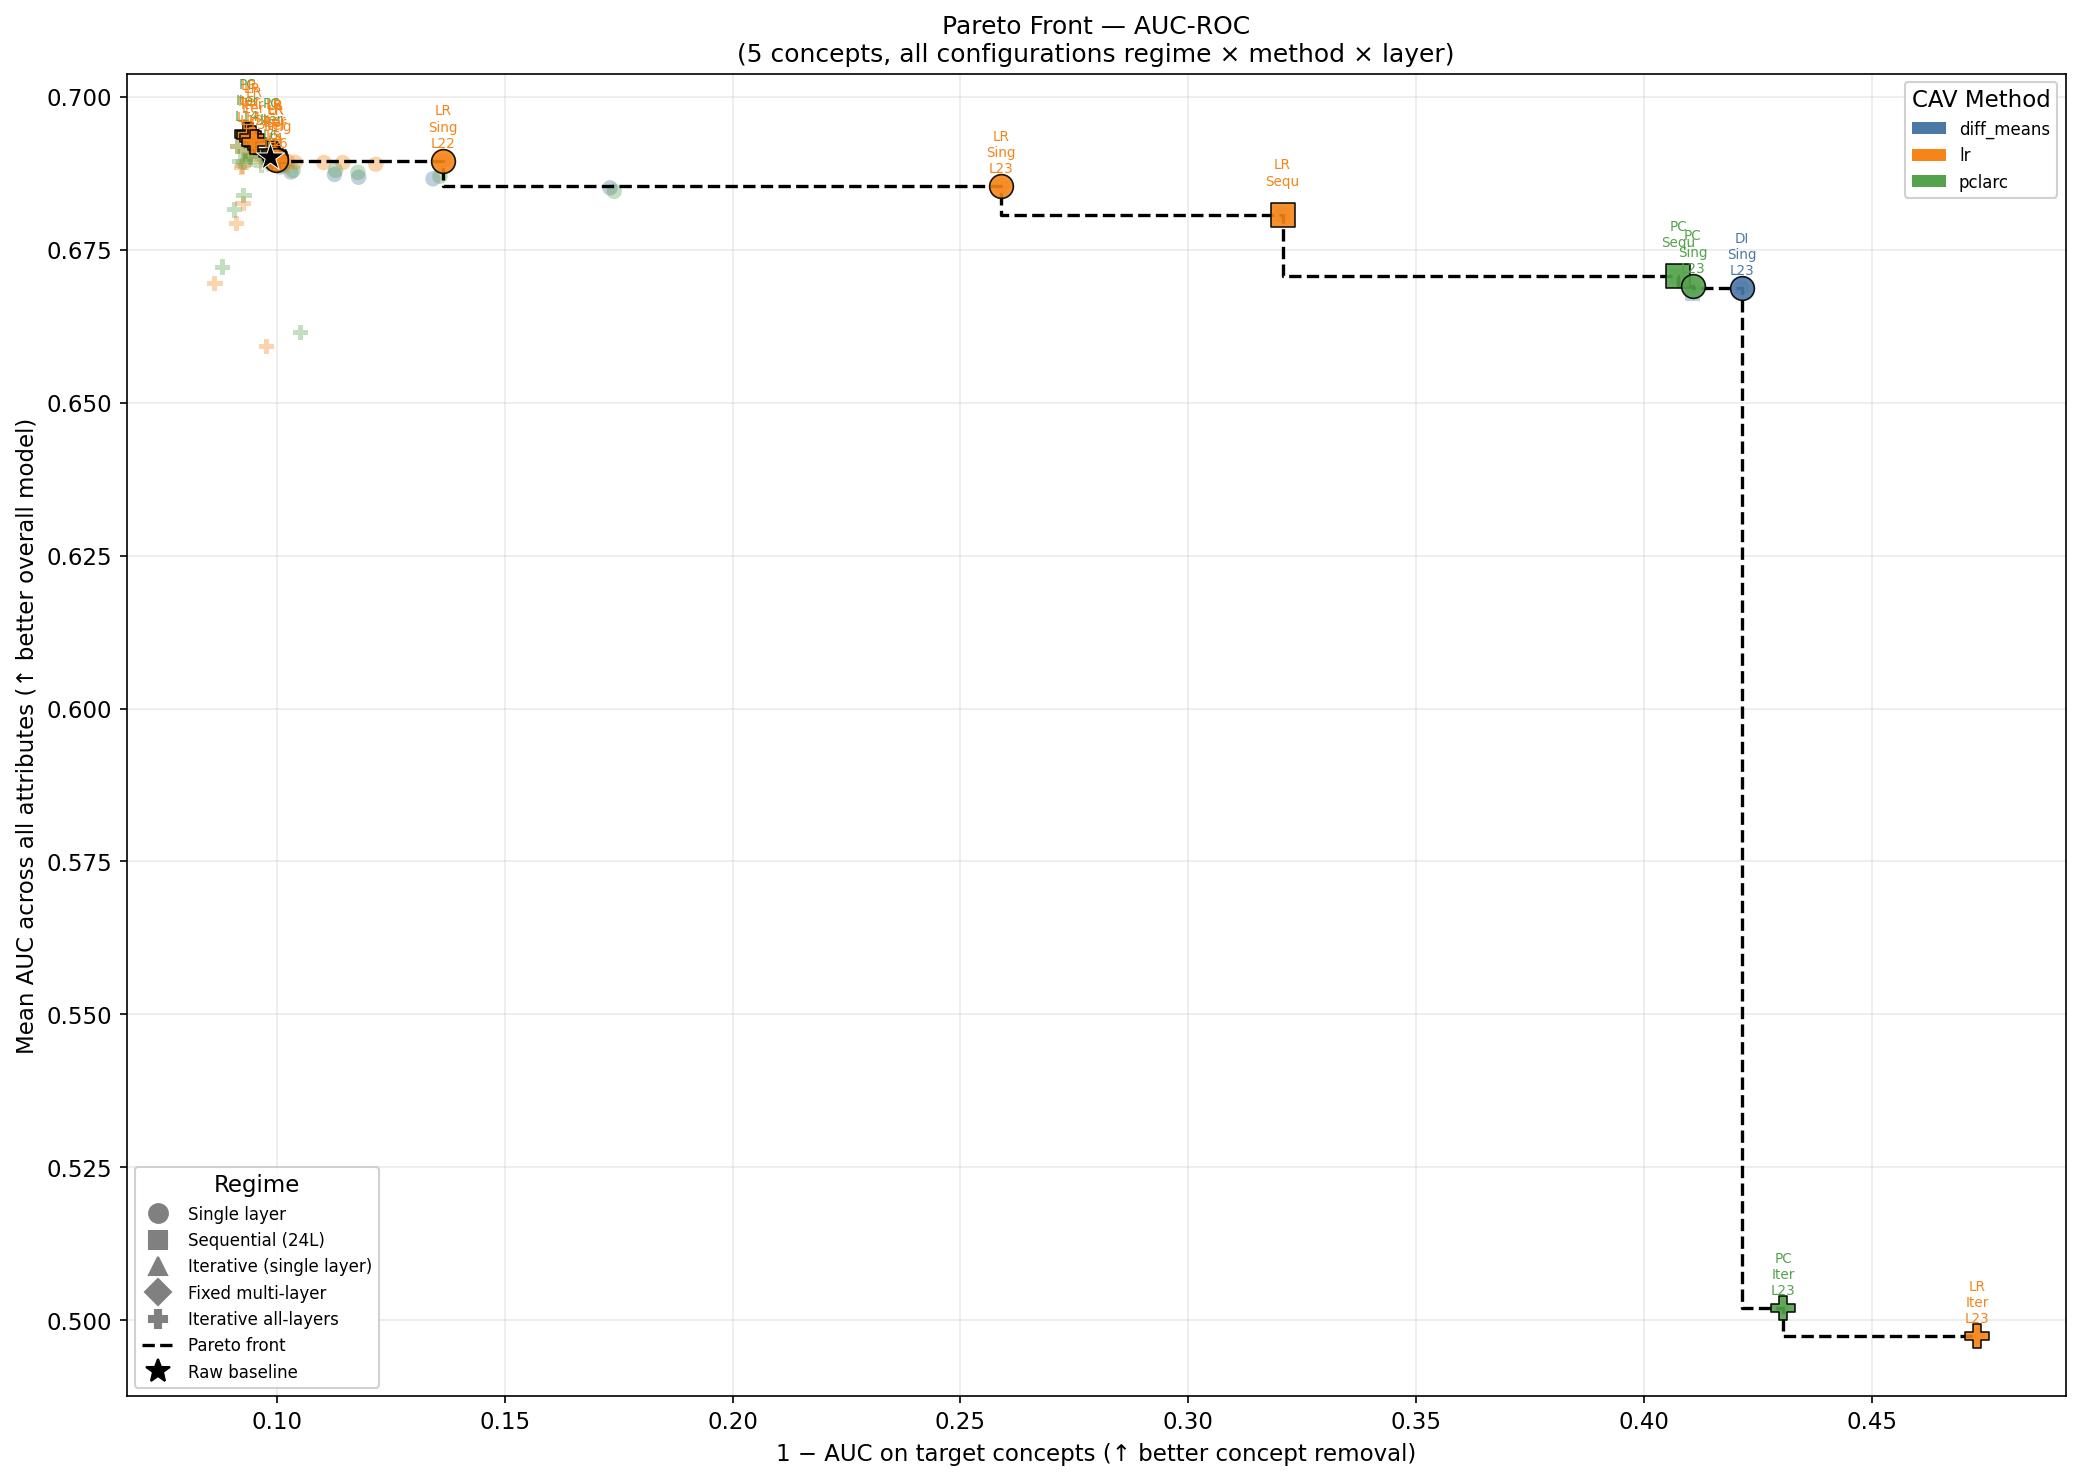

In [11]:
# ── PARETO AUC ────────────────────────────────────────────────────────────────
agg_auc = compute_pareto_data(df_deb, 'auc')
raw_auc = get_raw_point('auc')

fig, ax = plt.subplots(figsize=(14, 10))
plot_pareto(agg_auc, 'AUC', ax, raw_point=raw_auc)
ax.set_title(
    f'Pareto Front — AUC-ROC\n'
    f'({len(CONCEPTS)} concepts, all configurations regime × method × layer)'
)
plt.tight_layout()
plt.savefig(OUT_DIR / '06b_pareto_auc.png', dpi=150)
plt.show()

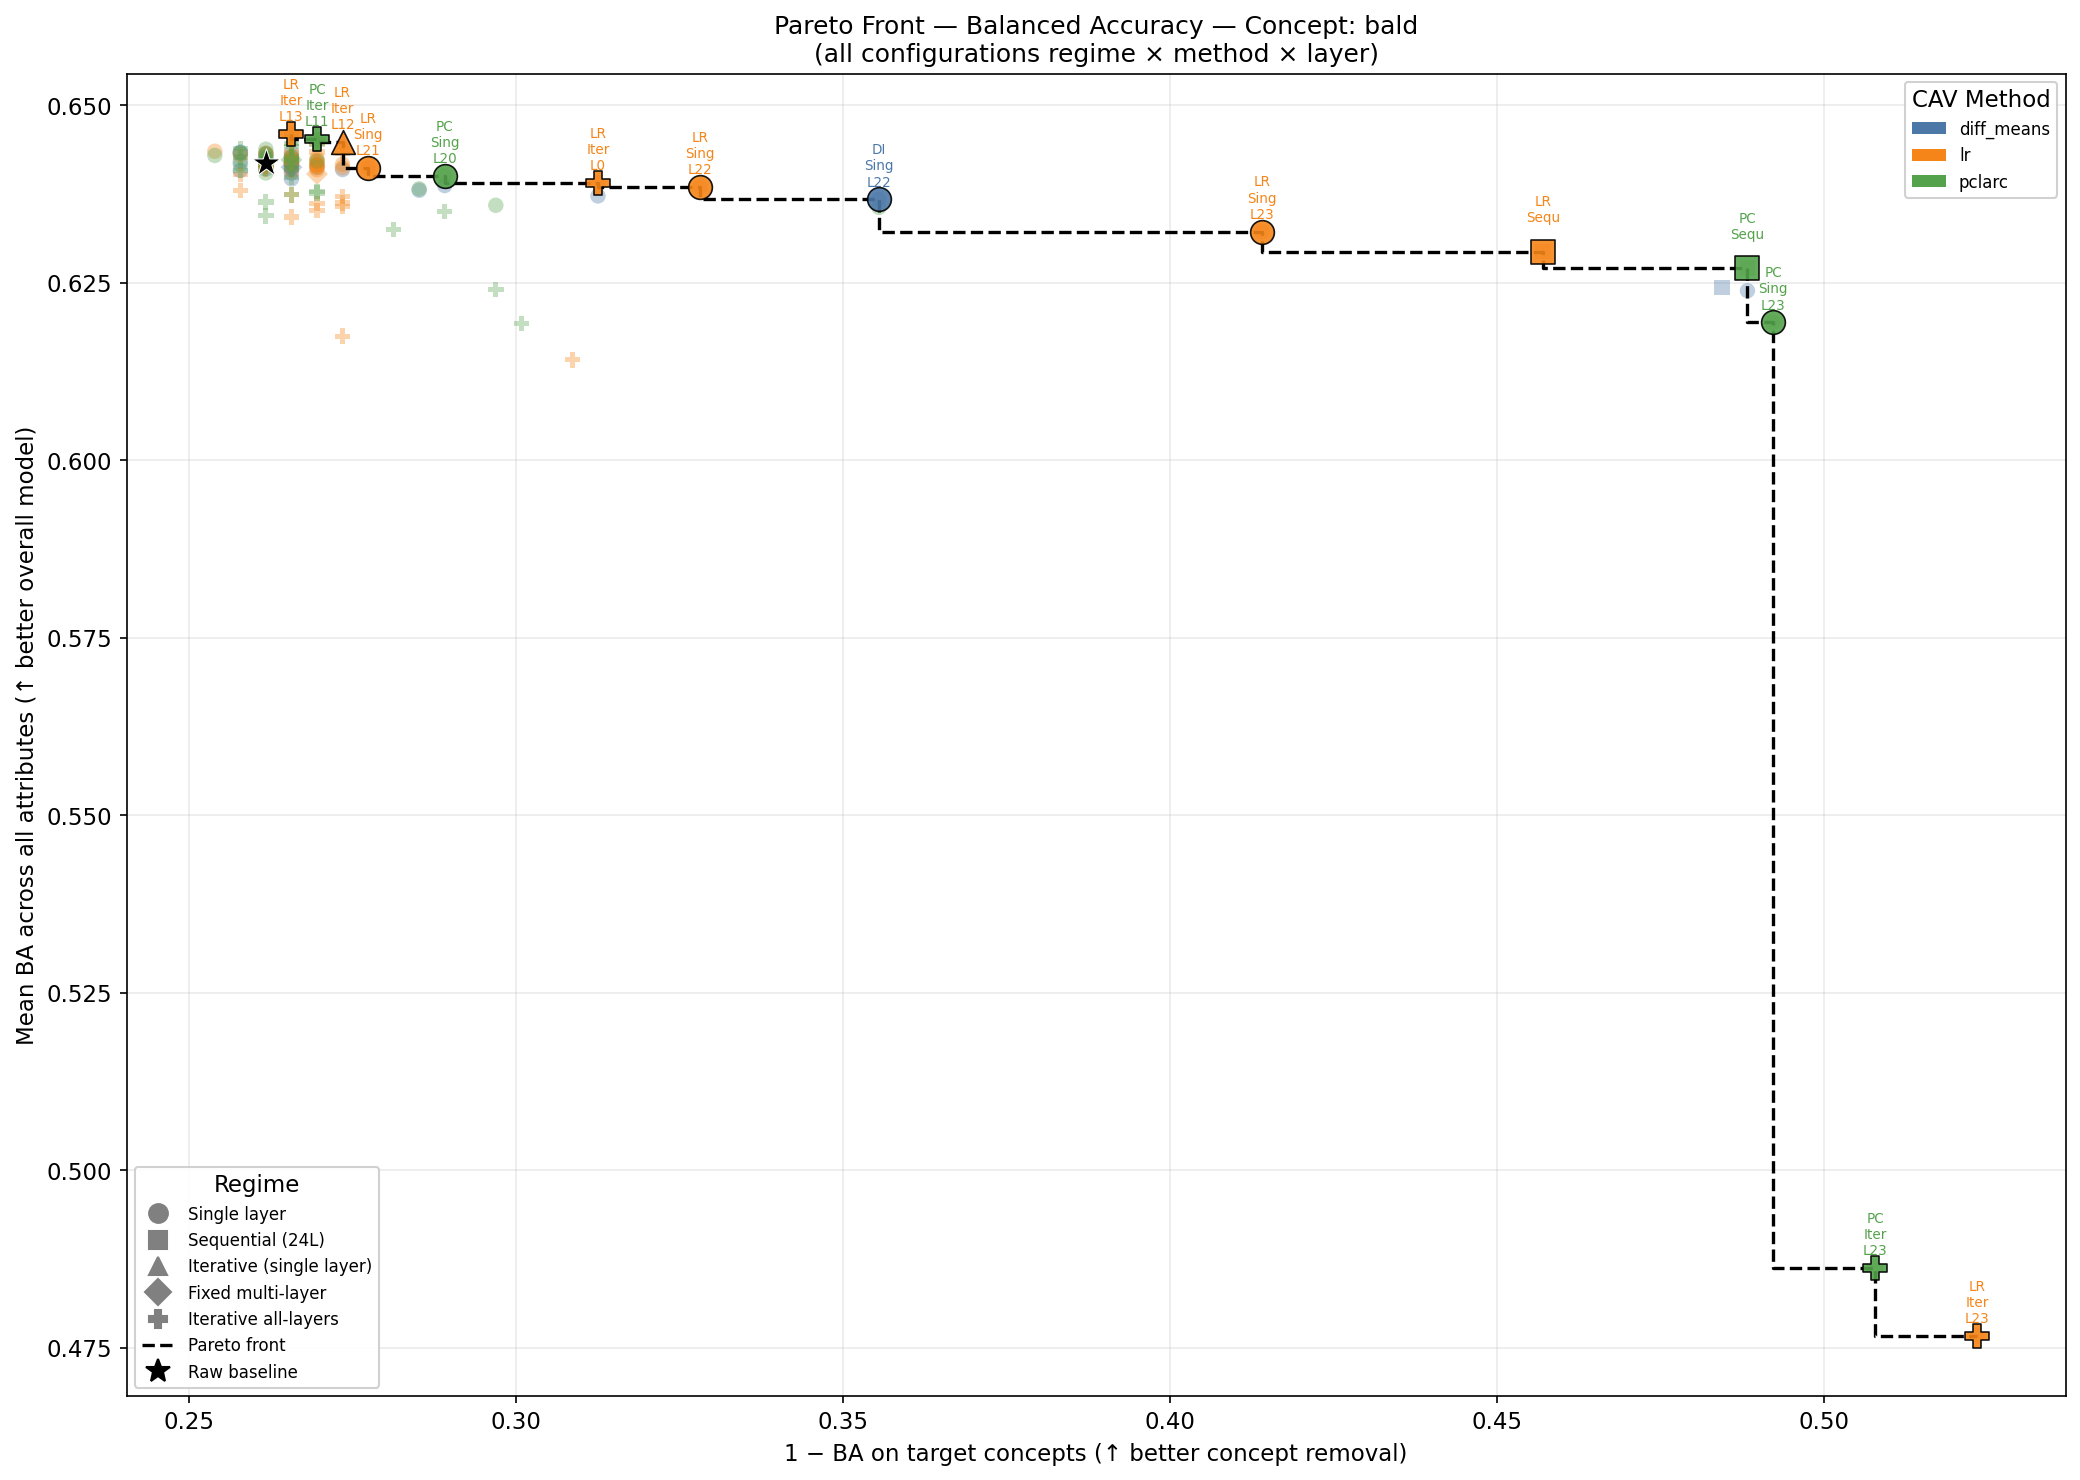

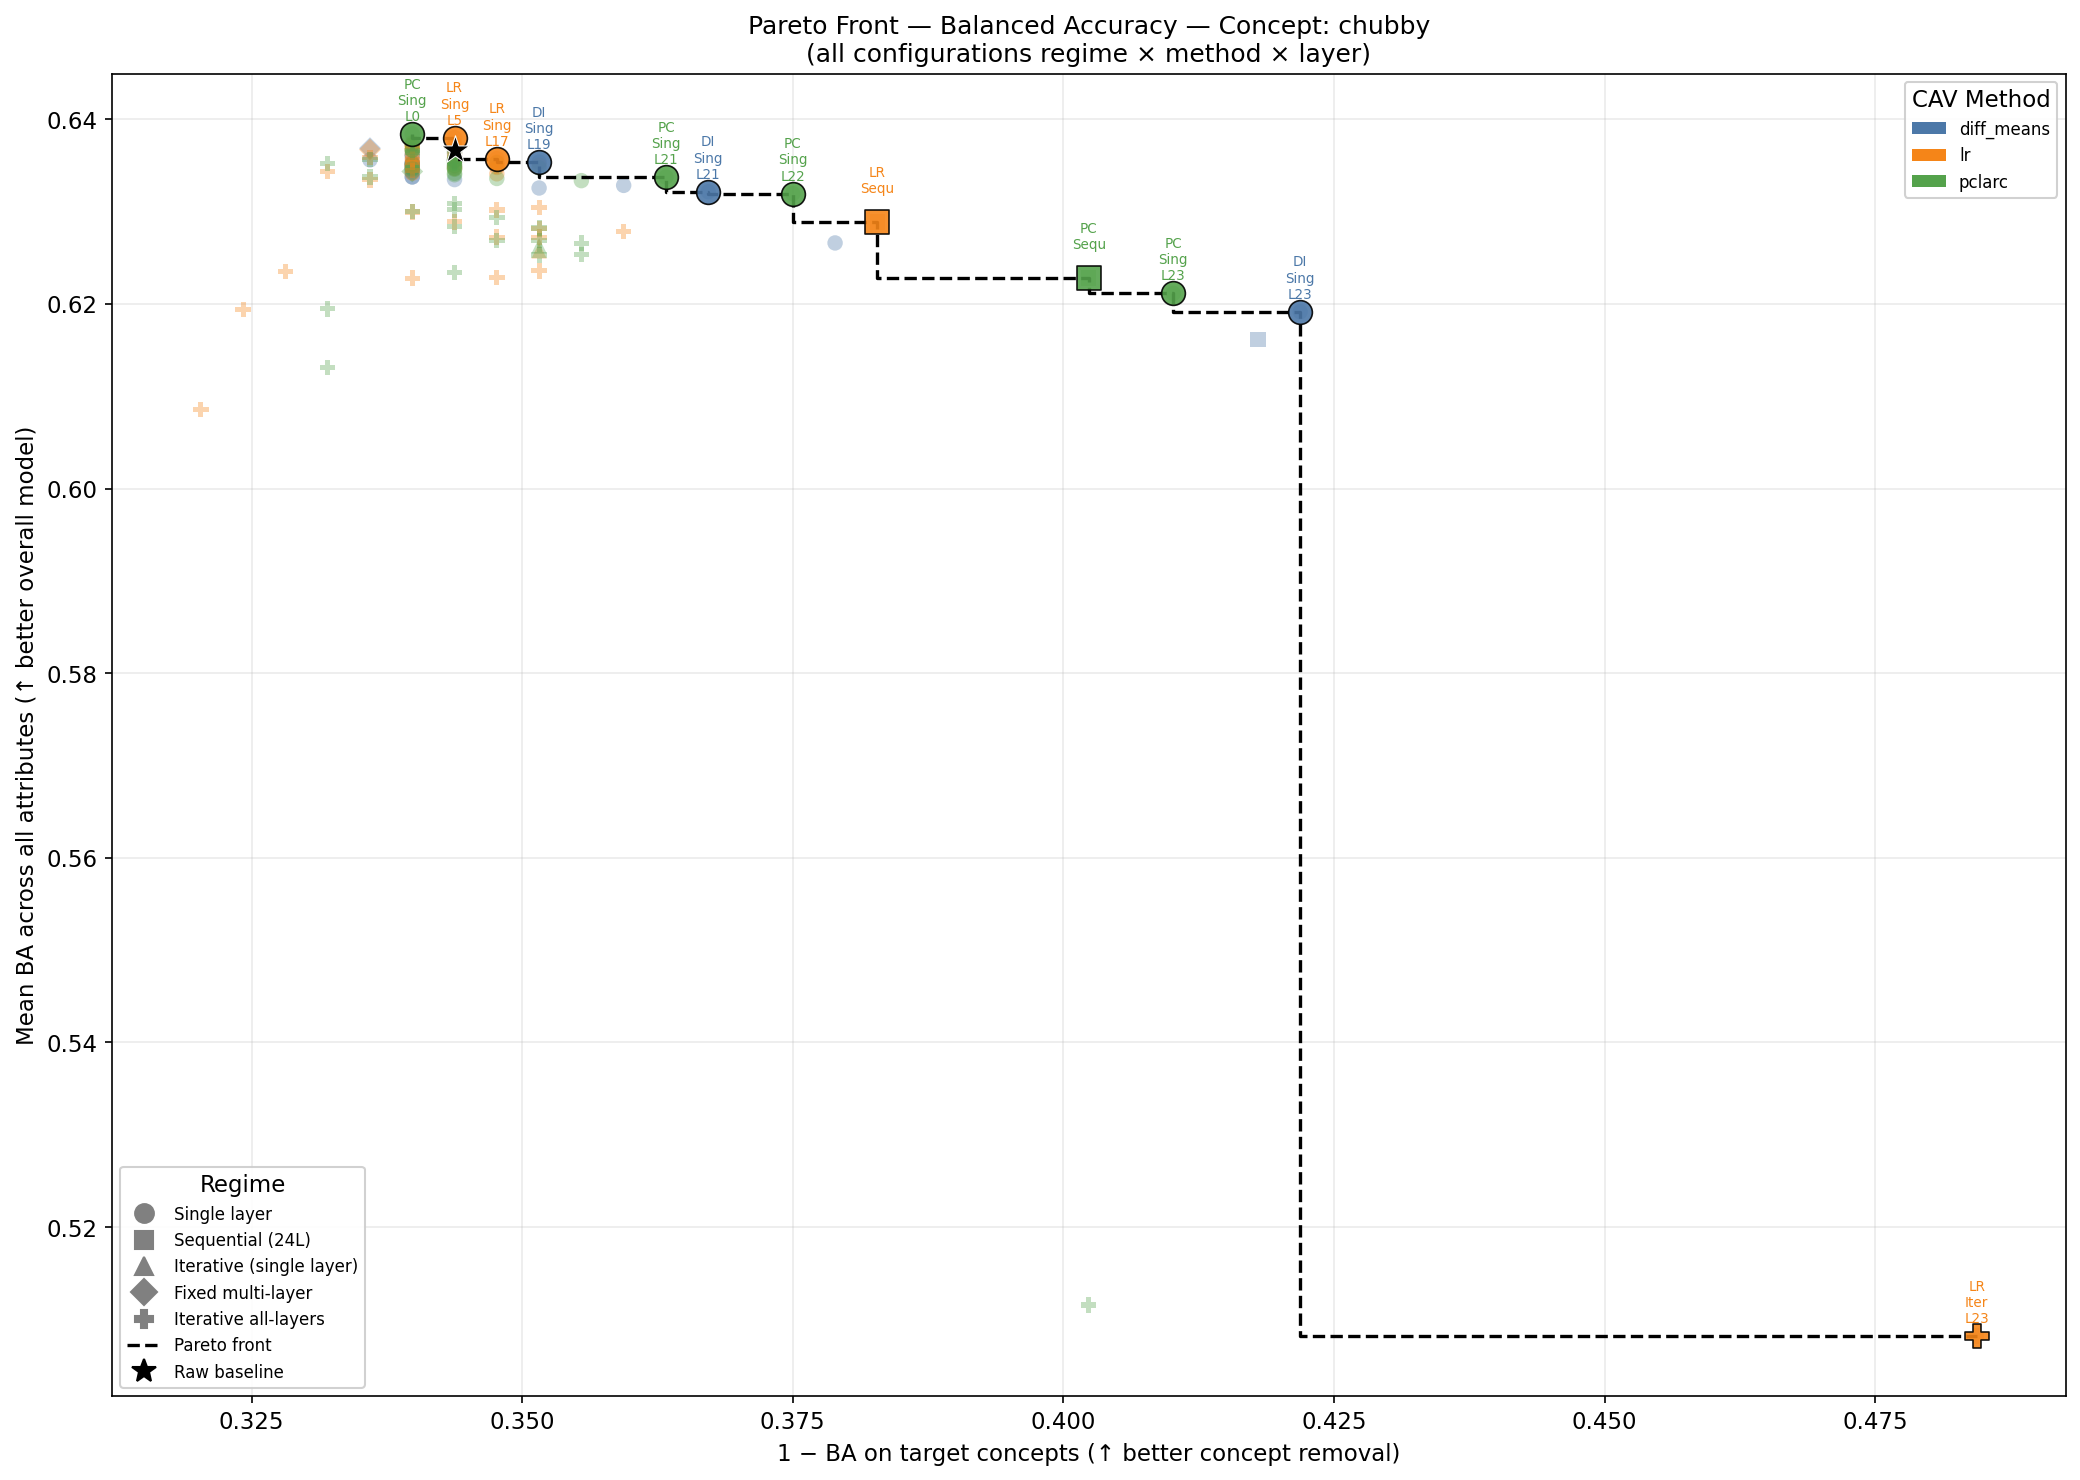

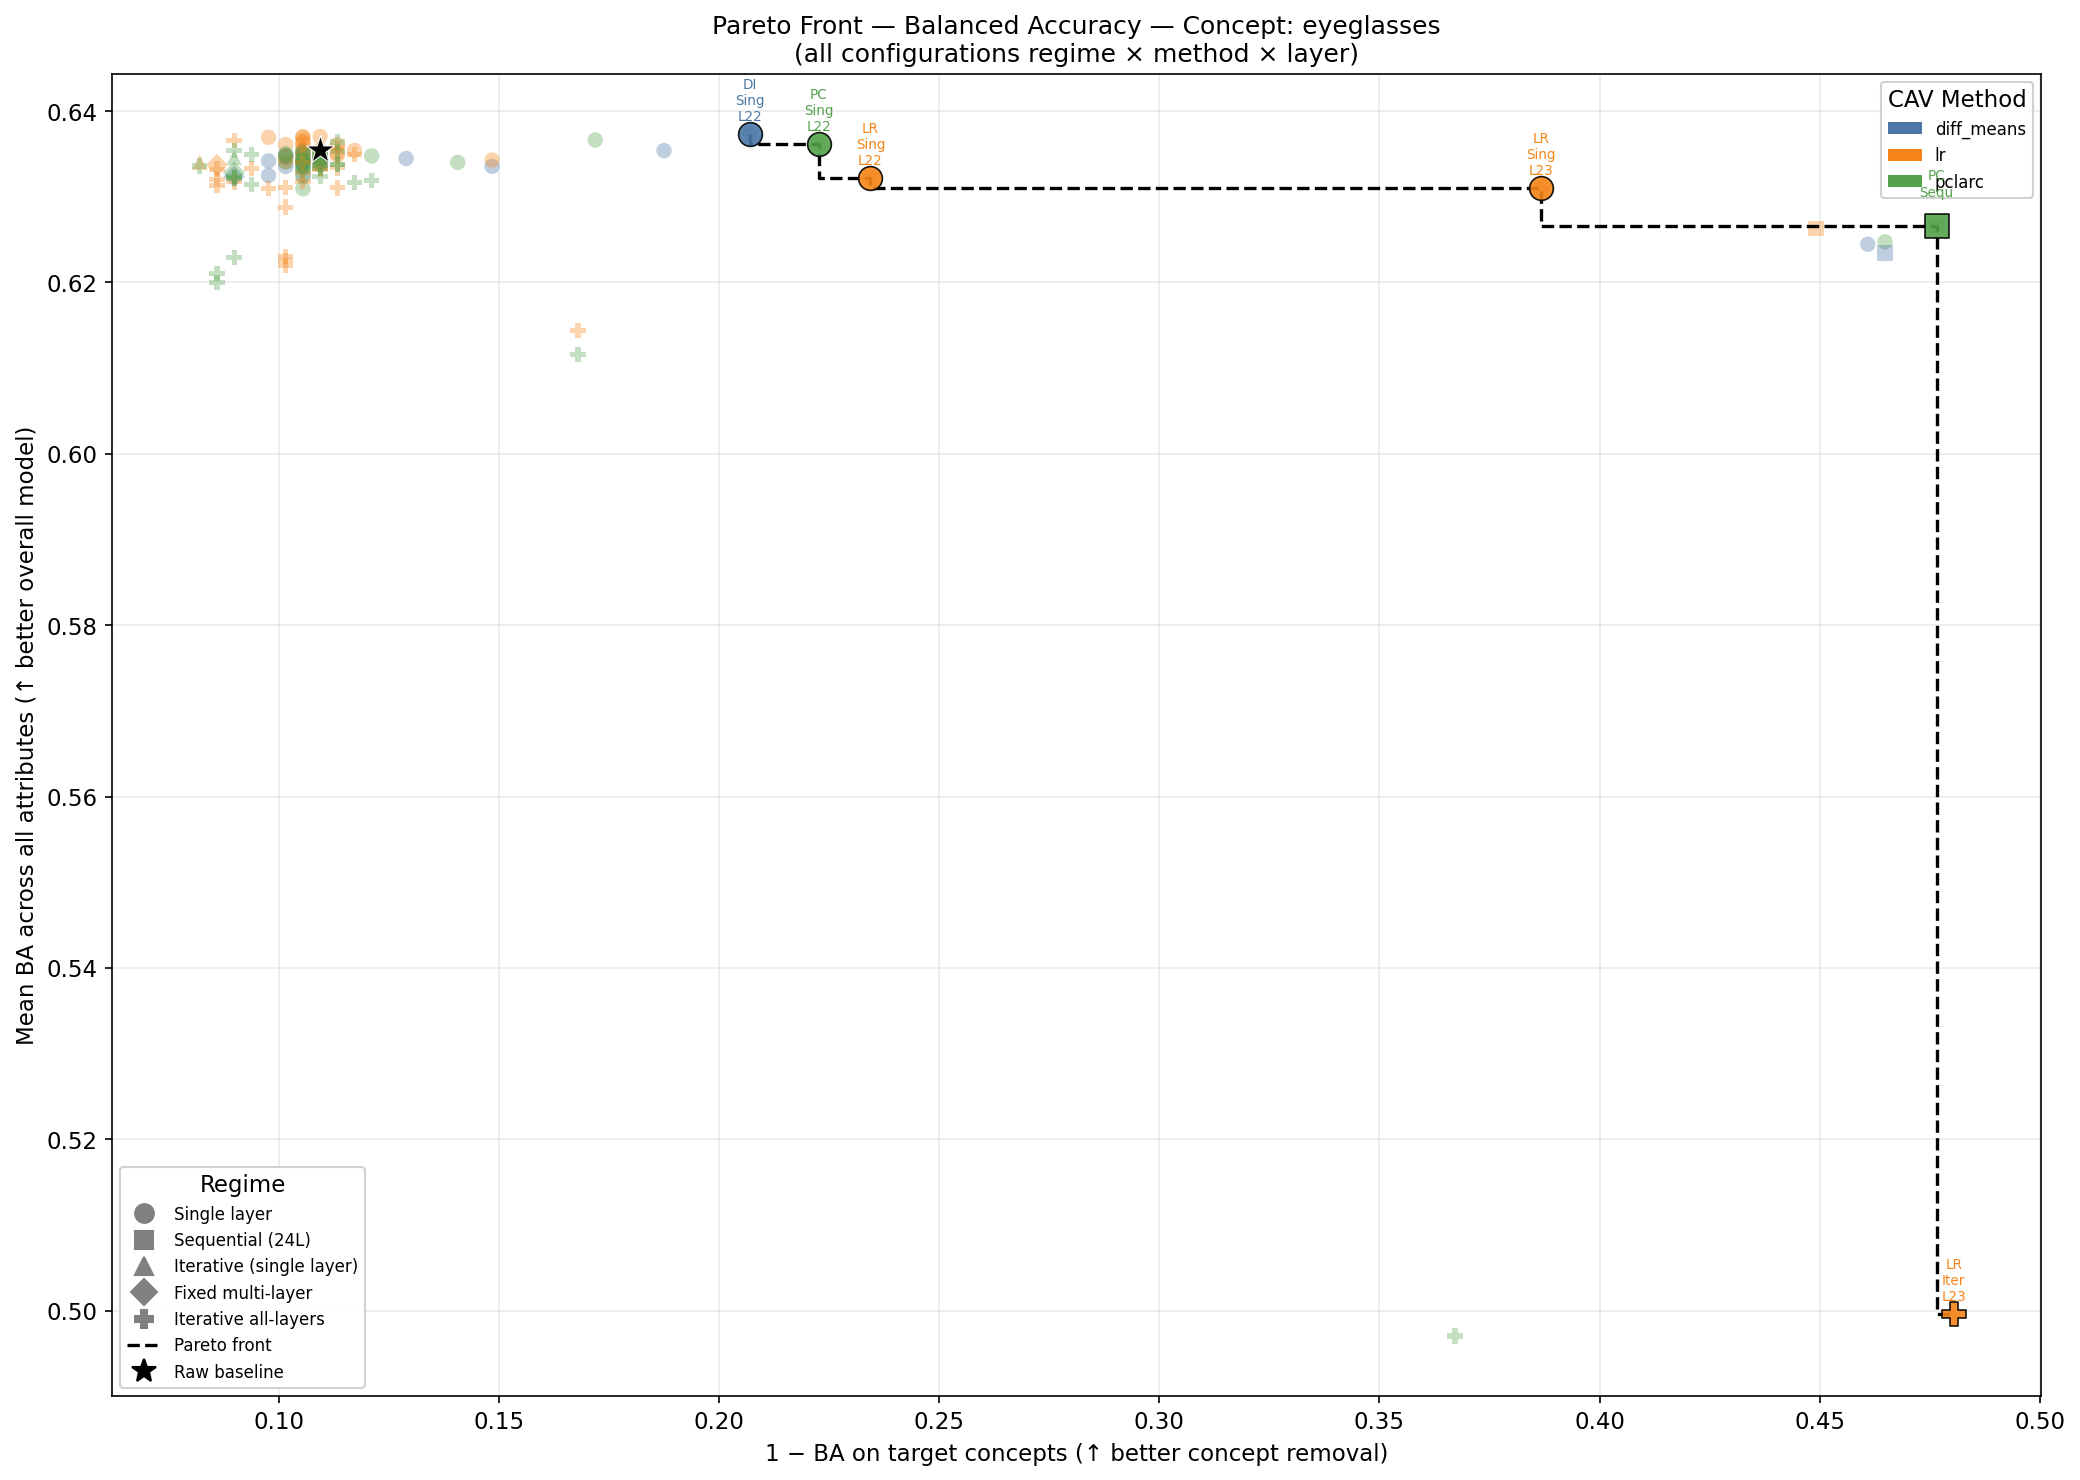

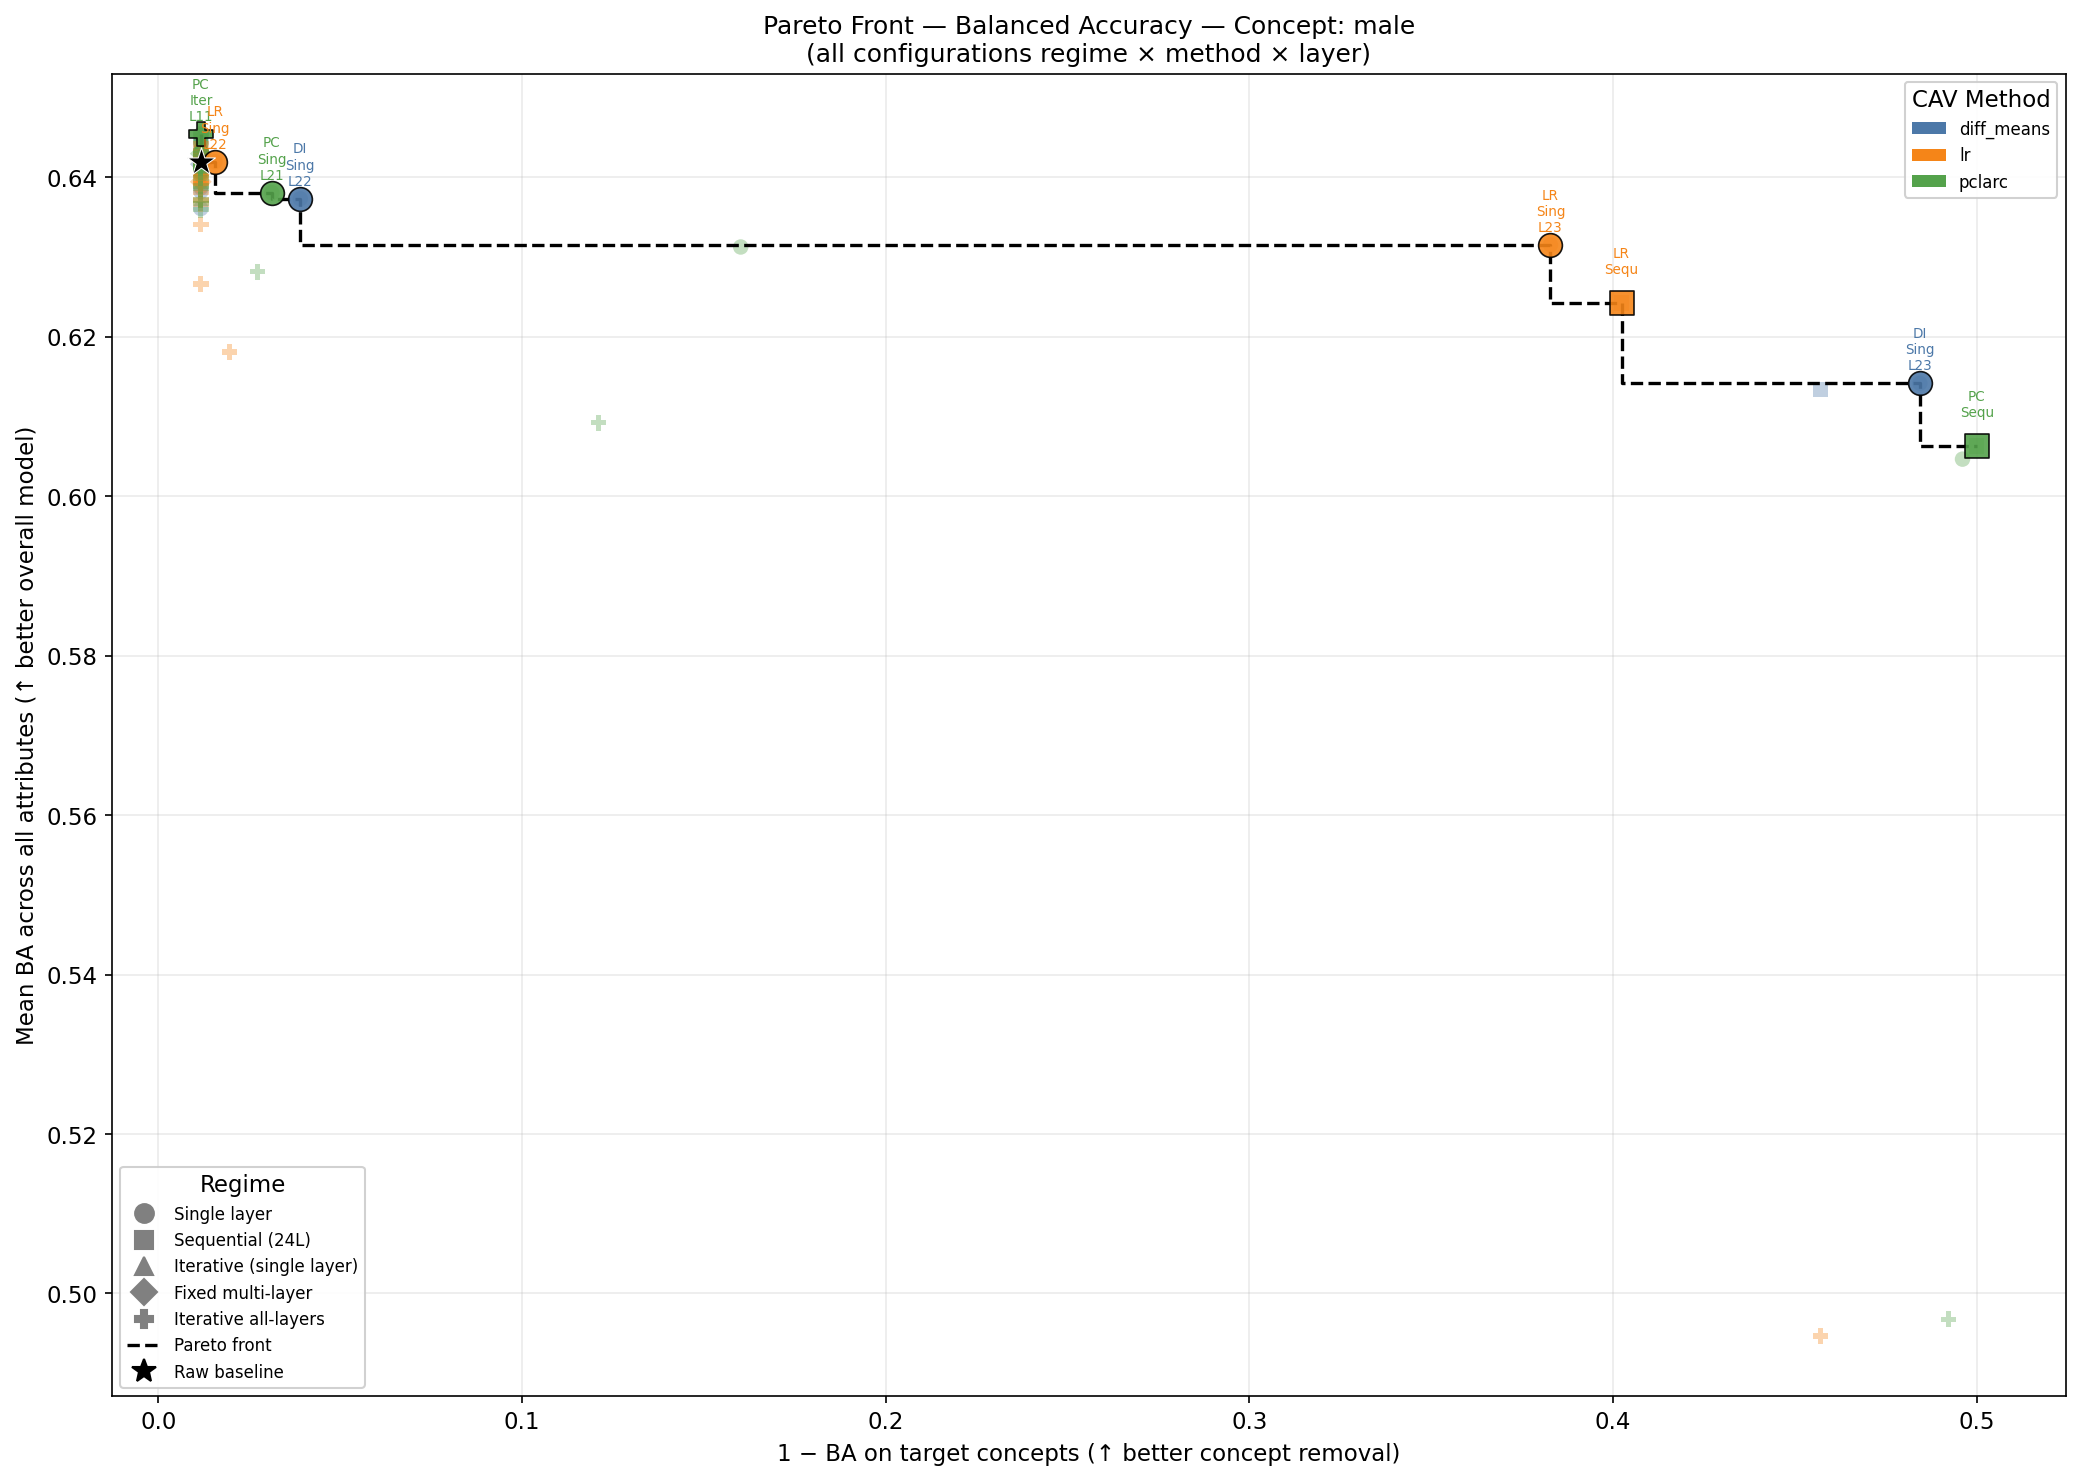

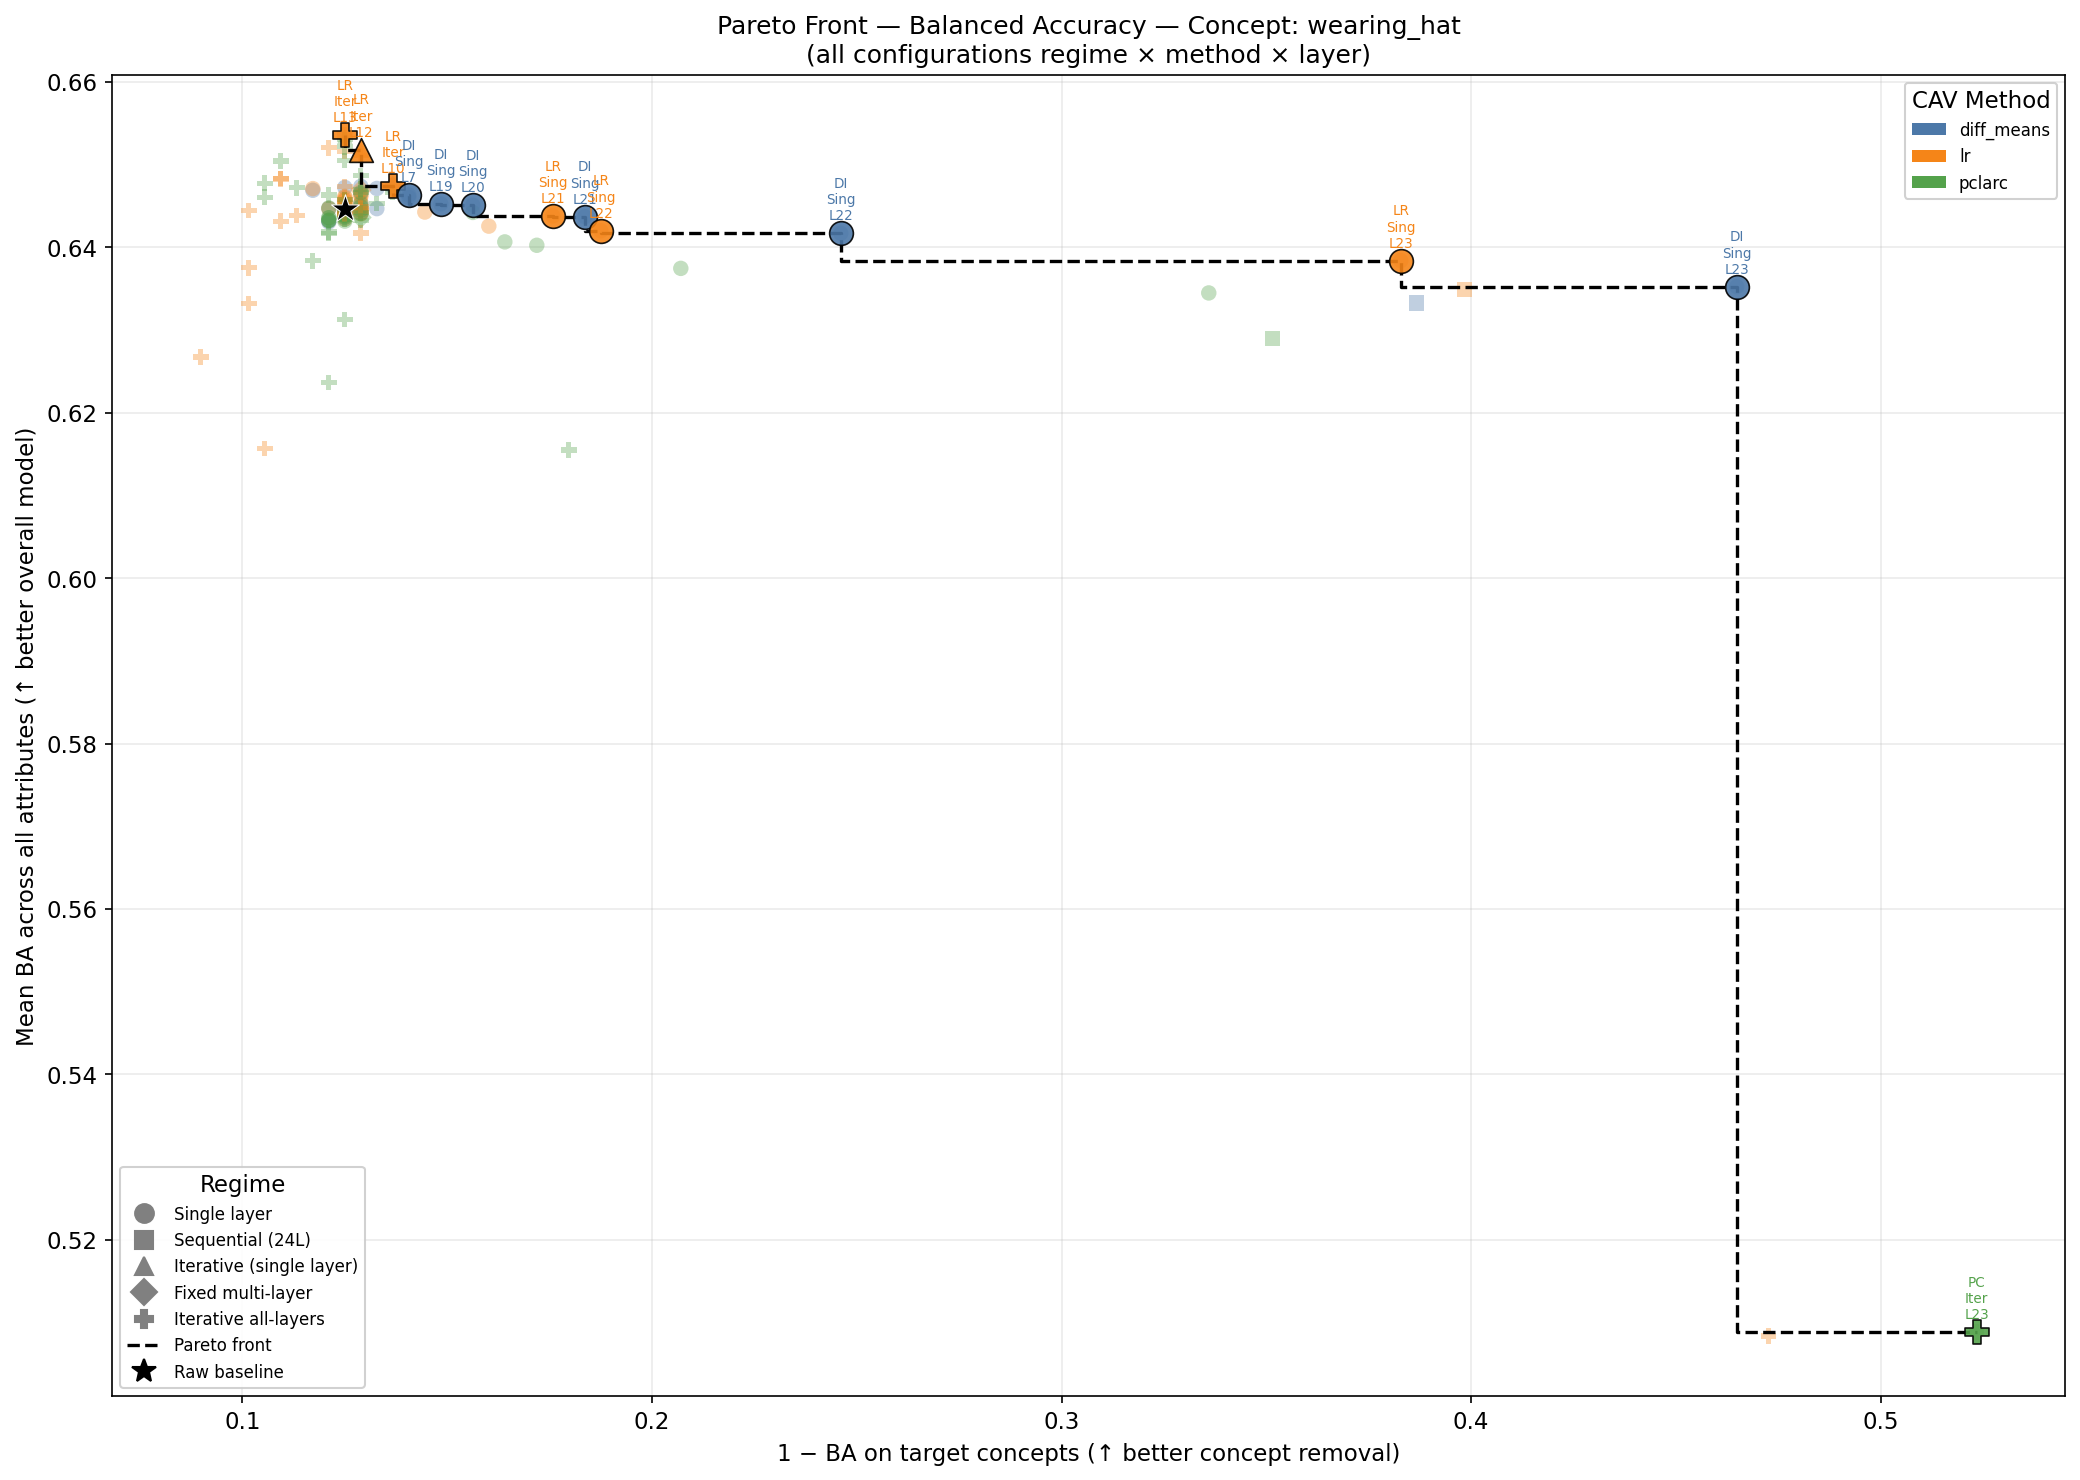

Generated 5 individual Max-Max Pareto plots for BA.


In [12]:
# ── PARETO BA PER CONCEPT ─────────────────────────────────────────────────────

config_cols = ['regime', 'method', 'debias_layer', 'n_iterations', 'n_layers']

for concept in CONCEPTS:
    # Filter data for the specific concept
    df_concept = df_deb[df_deb['concept_file'] == concept].copy()
    
    if df_concept.empty:
        print(f"Skipping {concept} - no debiased data.")
        continue
        
    # Calculate metric on target attribute and mean across all attributes
    df_concept['is_target'] = df_concept['target_attribute'] == concept
    
    target_per_config = (
        df_concept[df_concept['is_target']]
        .groupby(config_cols, dropna=False)['bal_acc']
        .mean()
        .reset_index()
        .rename(columns={'bal_acc': 'metric_target'})
    )
    
    all_per_config = (
        df_concept
        .groupby(config_cols, dropna=False)['bal_acc']
        .mean()
        .reset_index()
        .rename(columns={'bal_acc': 'metric_all'})
    )
    
    agg_concept = target_per_config.merge(all_per_config, on=config_cols)
    agg_concept['x'] = 1 - agg_concept['metric_target']
    agg_concept['y'] = agg_concept['metric_all']
    
    # Calculate raw baseline for this specific concept
    raw_rows_concept = df[(df['regime'] == 'raw') & (df['concept_file'] == concept)]
    tgt_raw = raw_rows_concept[raw_rows_concept['target_attribute'] == concept]['bal_acc']
    
    raw_point = None
    if not tgt_raw.empty:
        tgt_val = tgt_raw.mean()
        all_val = raw_rows_concept['bal_acc'].mean()
        raw_point = (1 - tgt_val, all_val)
        
    fig, ax = plt.subplots(figsize=(14, 10))
    plot_pareto(agg_concept, 'BA', ax, raw_point=raw_point)
    
    ax.set_title(
        f'Pareto Front — Balanced Accuracy — Concept: {concept}\n'
        f'(all configurations regime × method × layer)'
    )
    plt.tight_layout()
    
    # Clean filename (just in case concept names contain problematic characters)
    safe_concept_name = str(concept).replace('/', '_').replace(' ', '_')
    plt.savefig(OUT_DIR / f'06a_pareto_ba_{safe_concept_name}.png', dpi=150)
    plt.show()
    plt.close(fig) # Prevent memory leaks when generating multiple plots

print(f"Generated {len(CONCEPTS)} individual Max-Max Pareto plots for BA.")

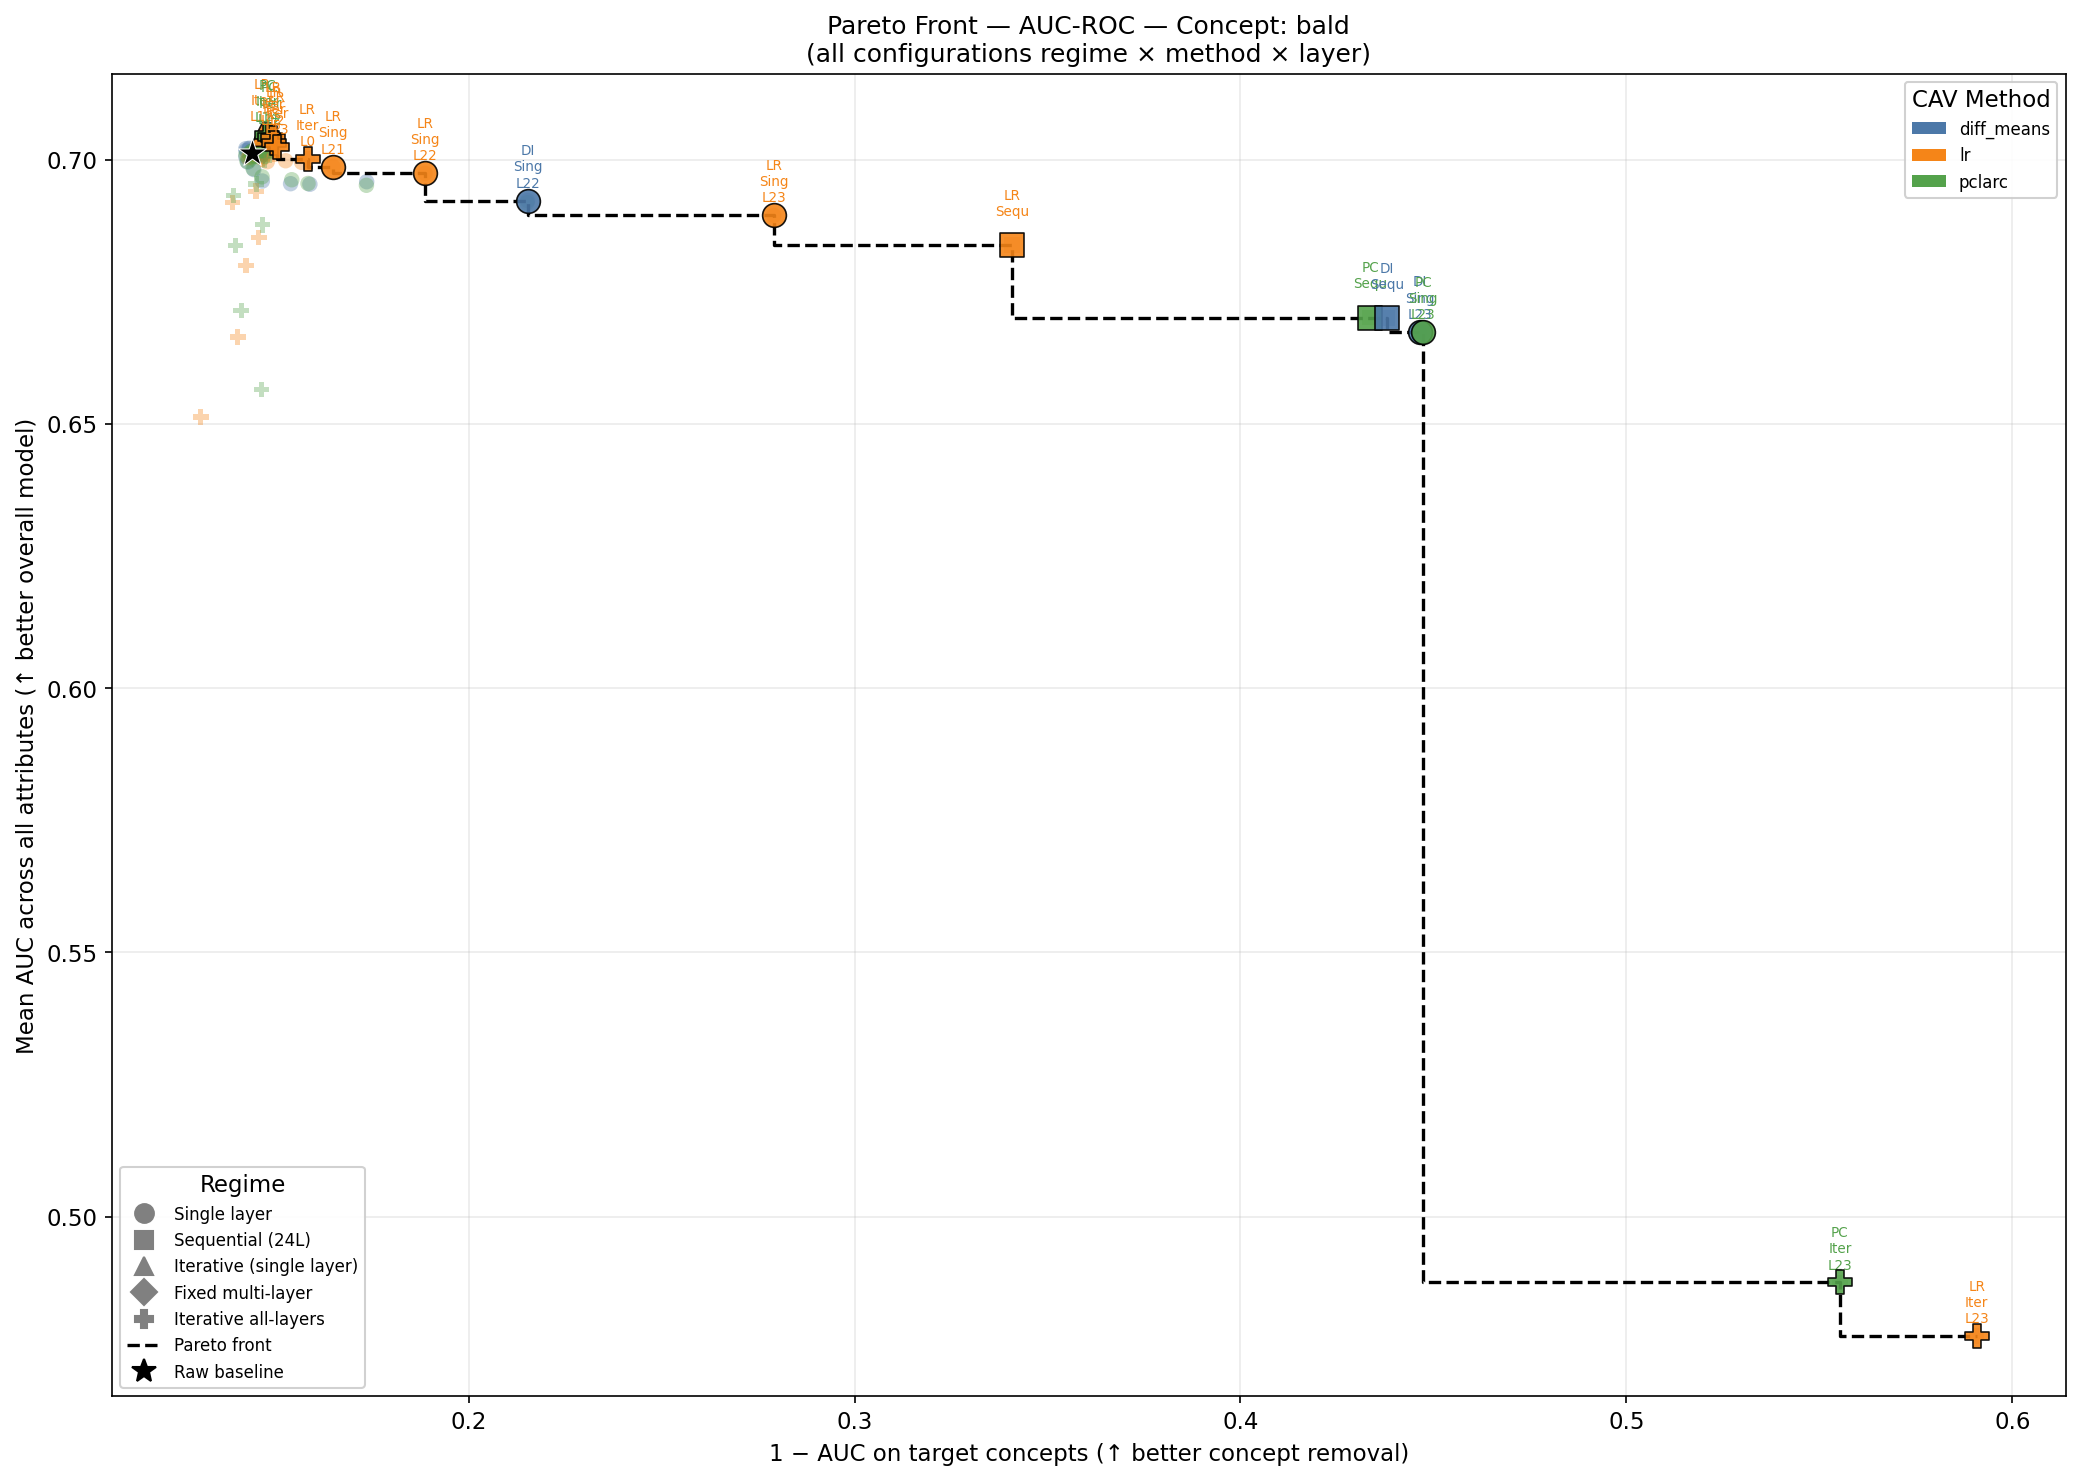

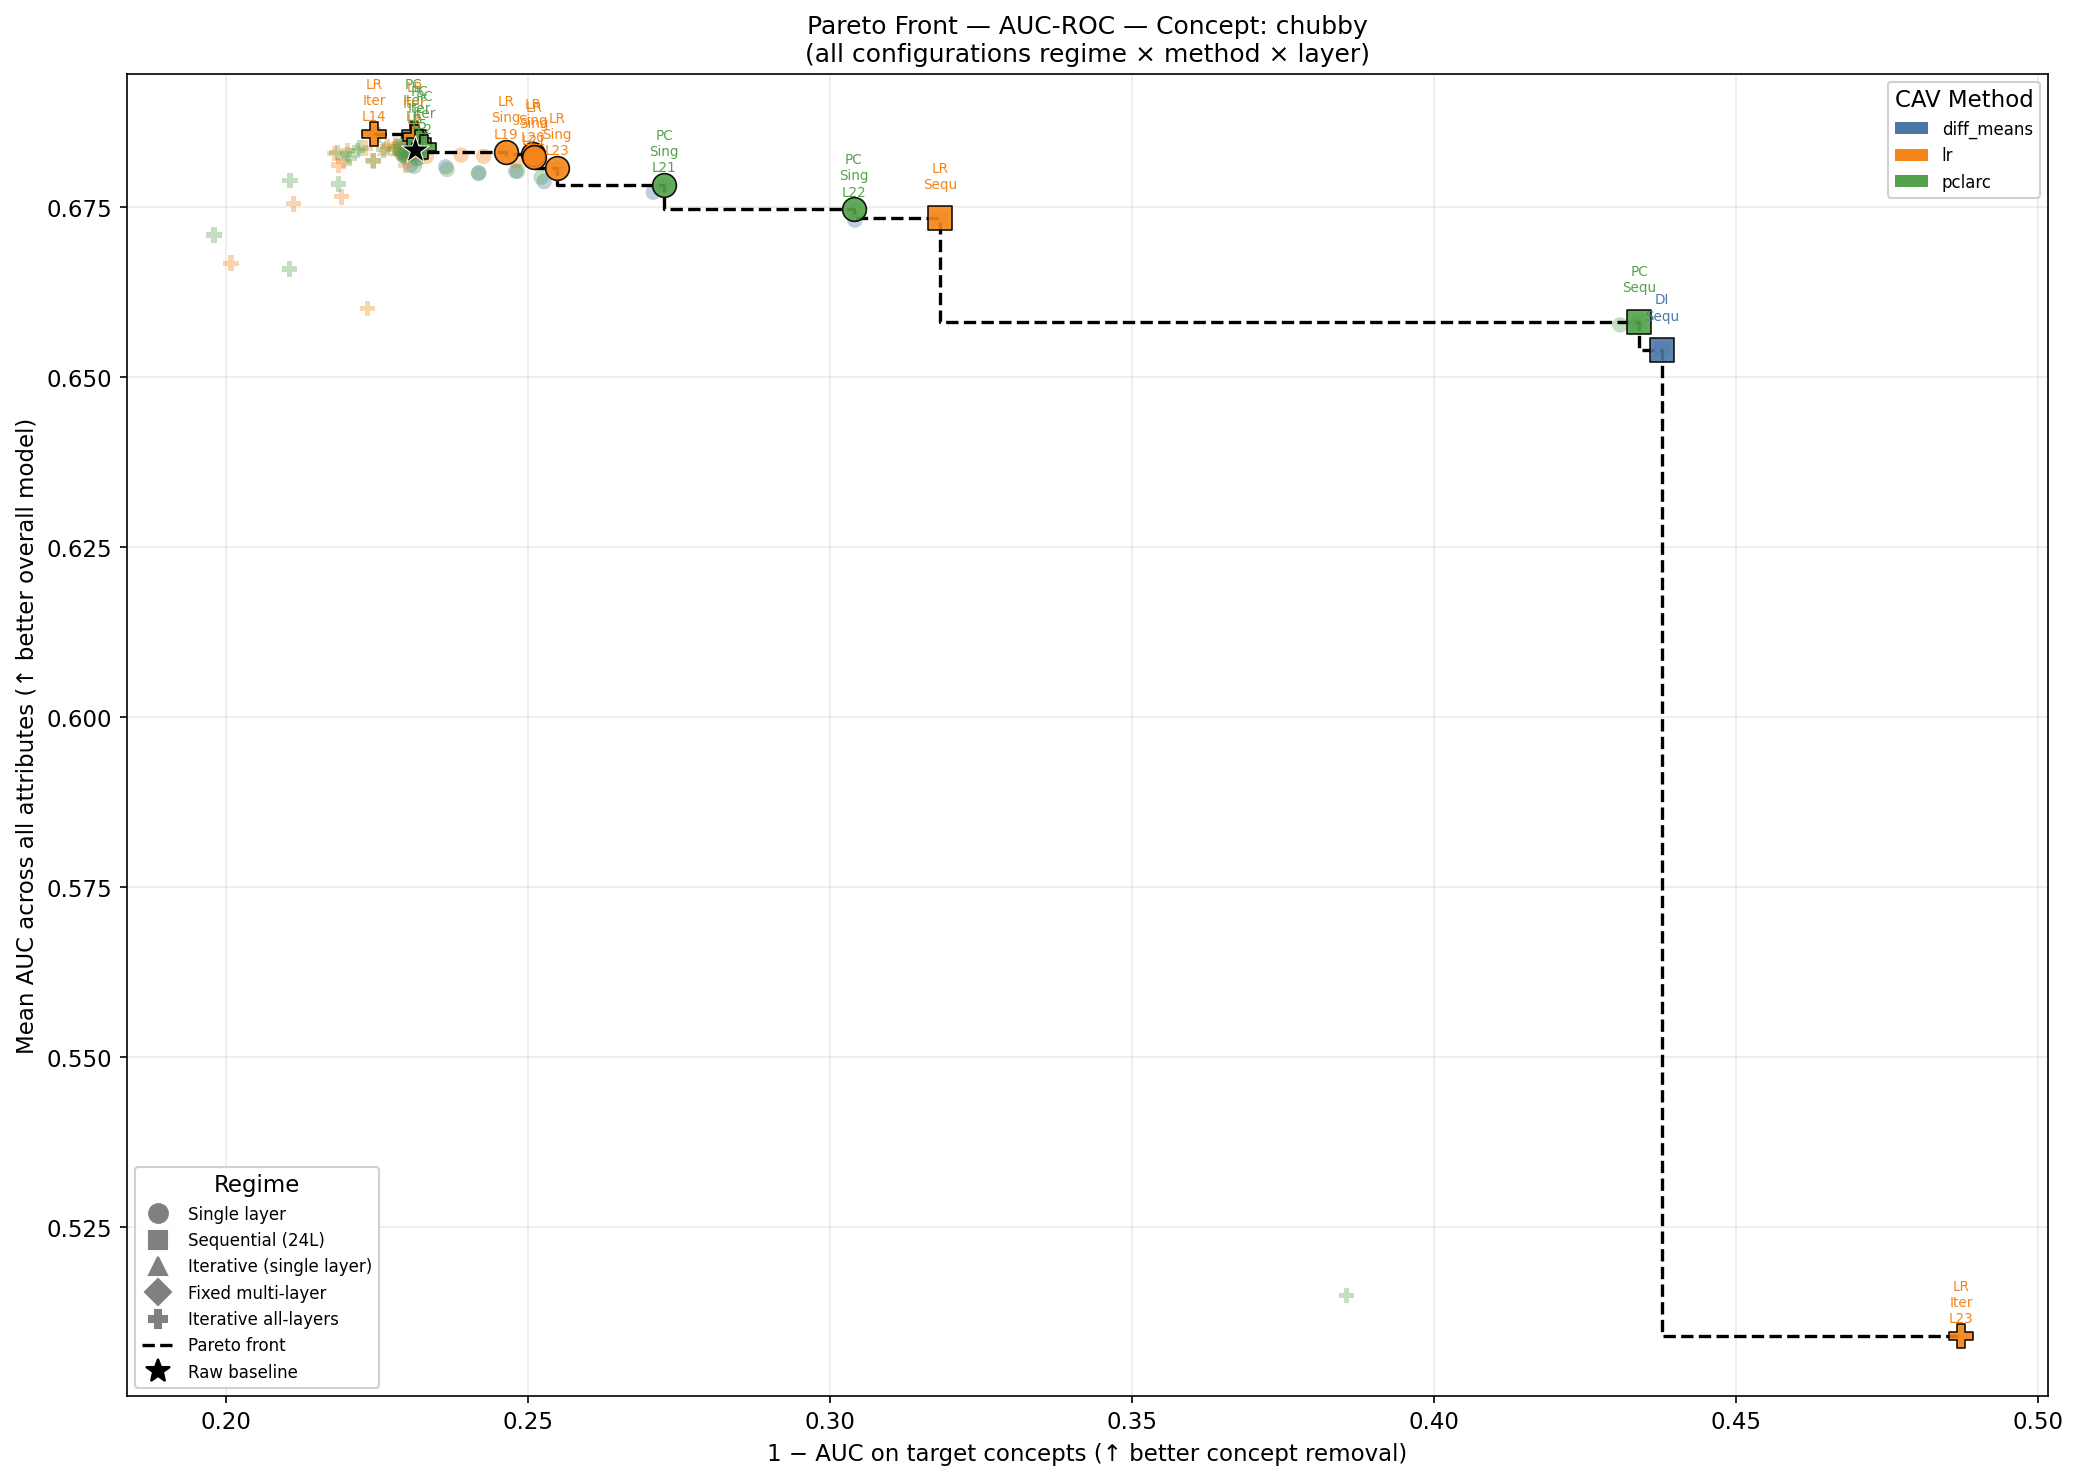

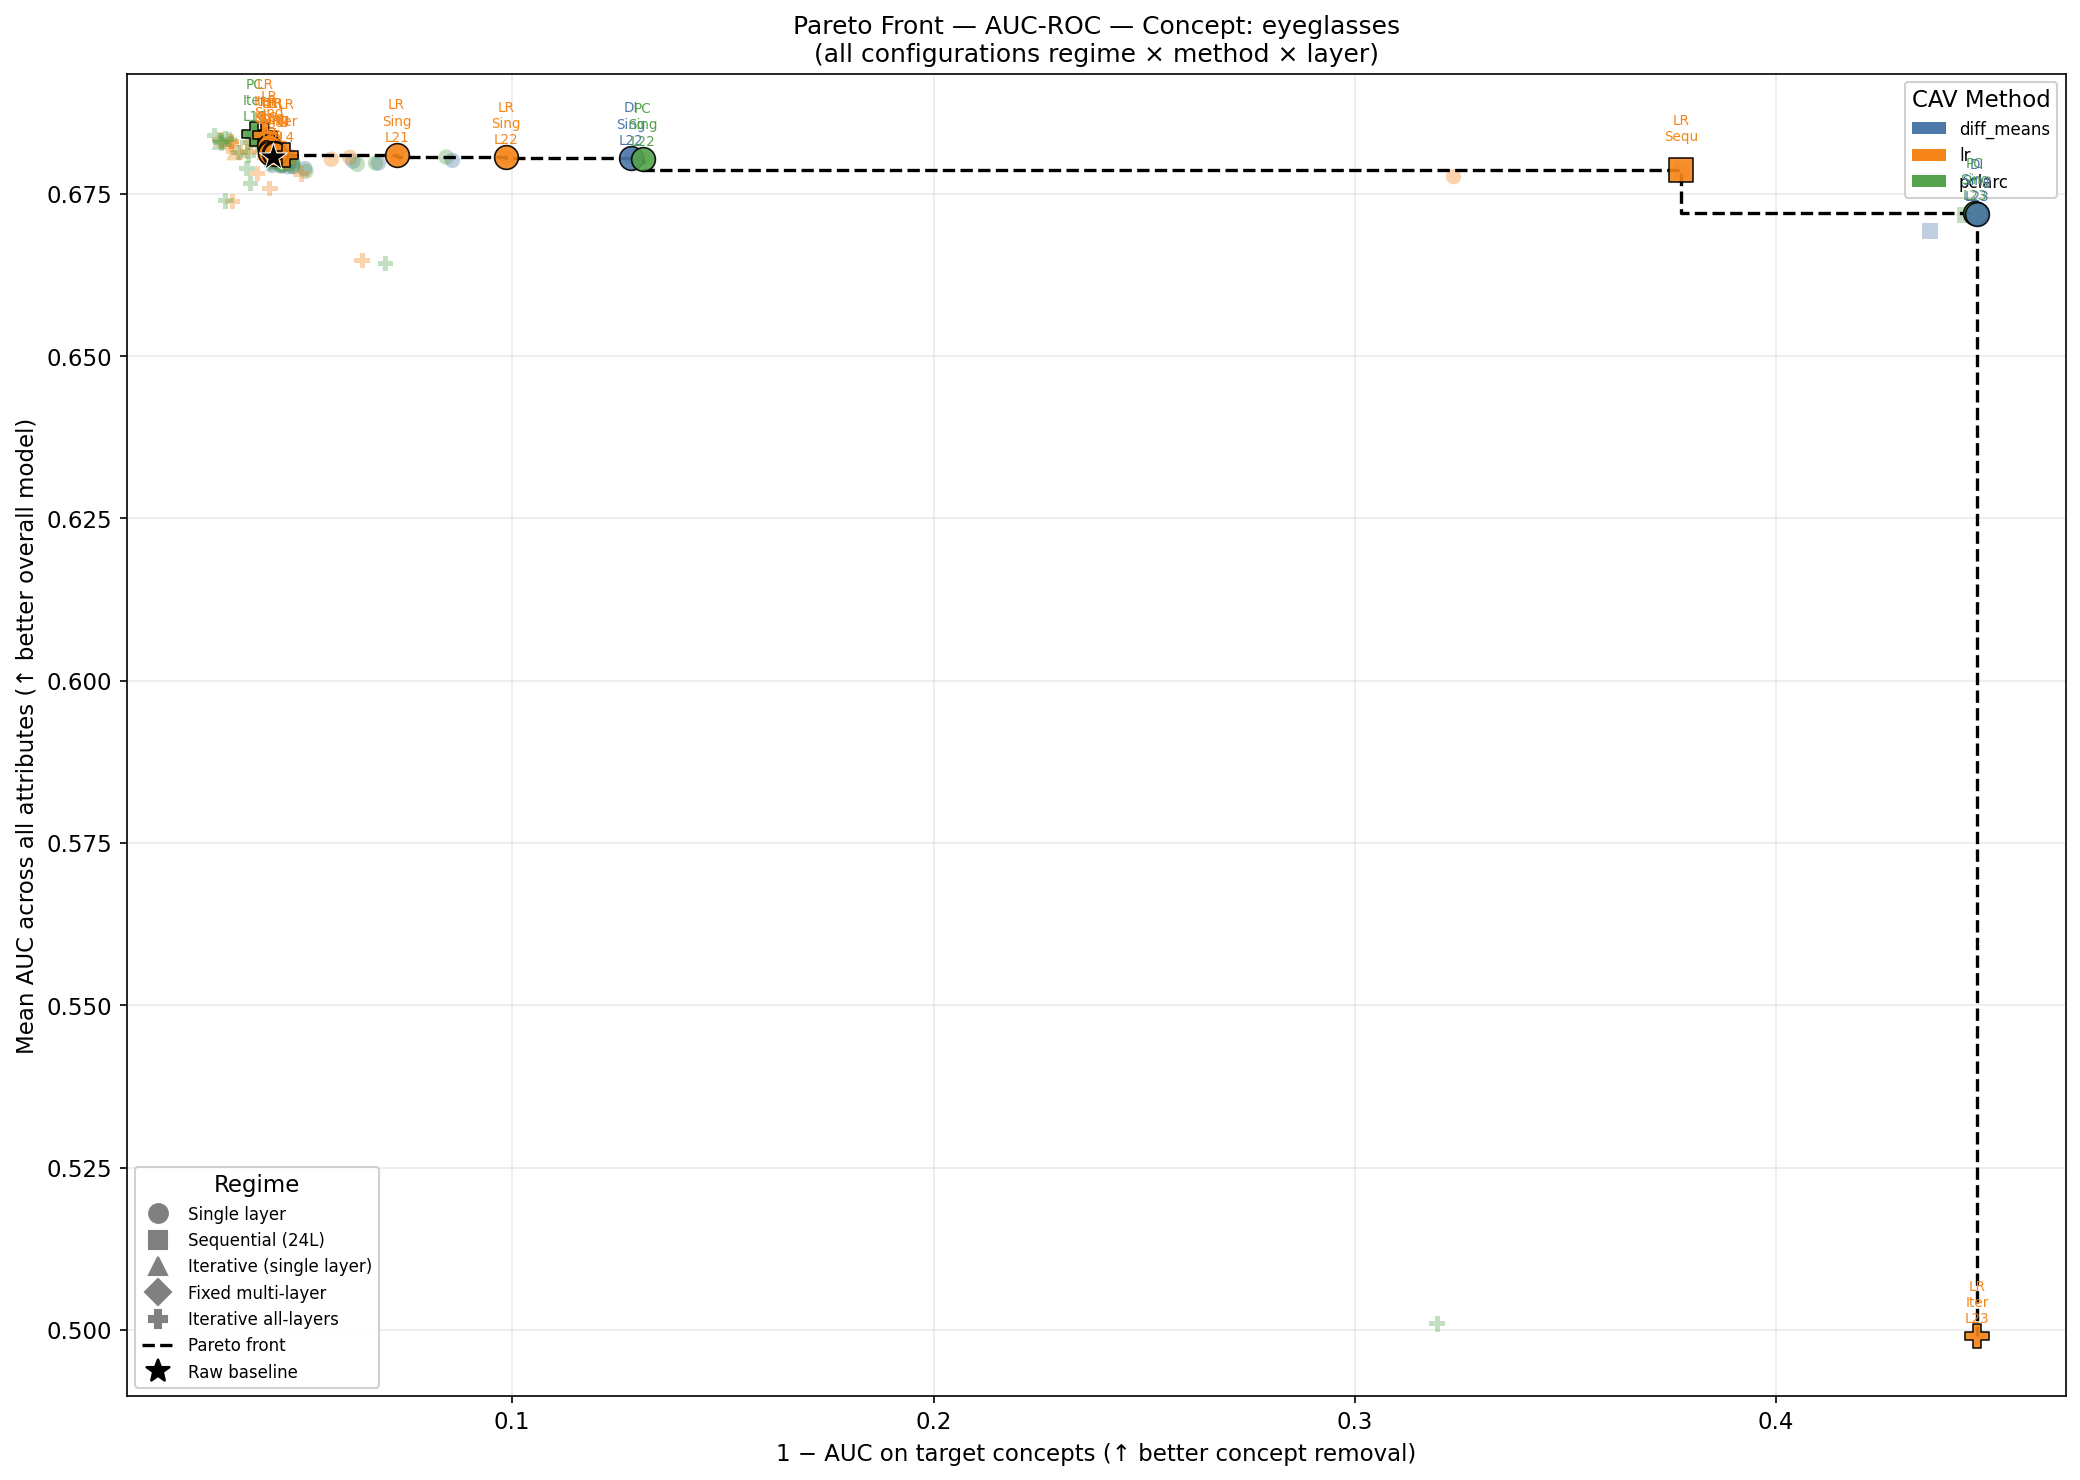

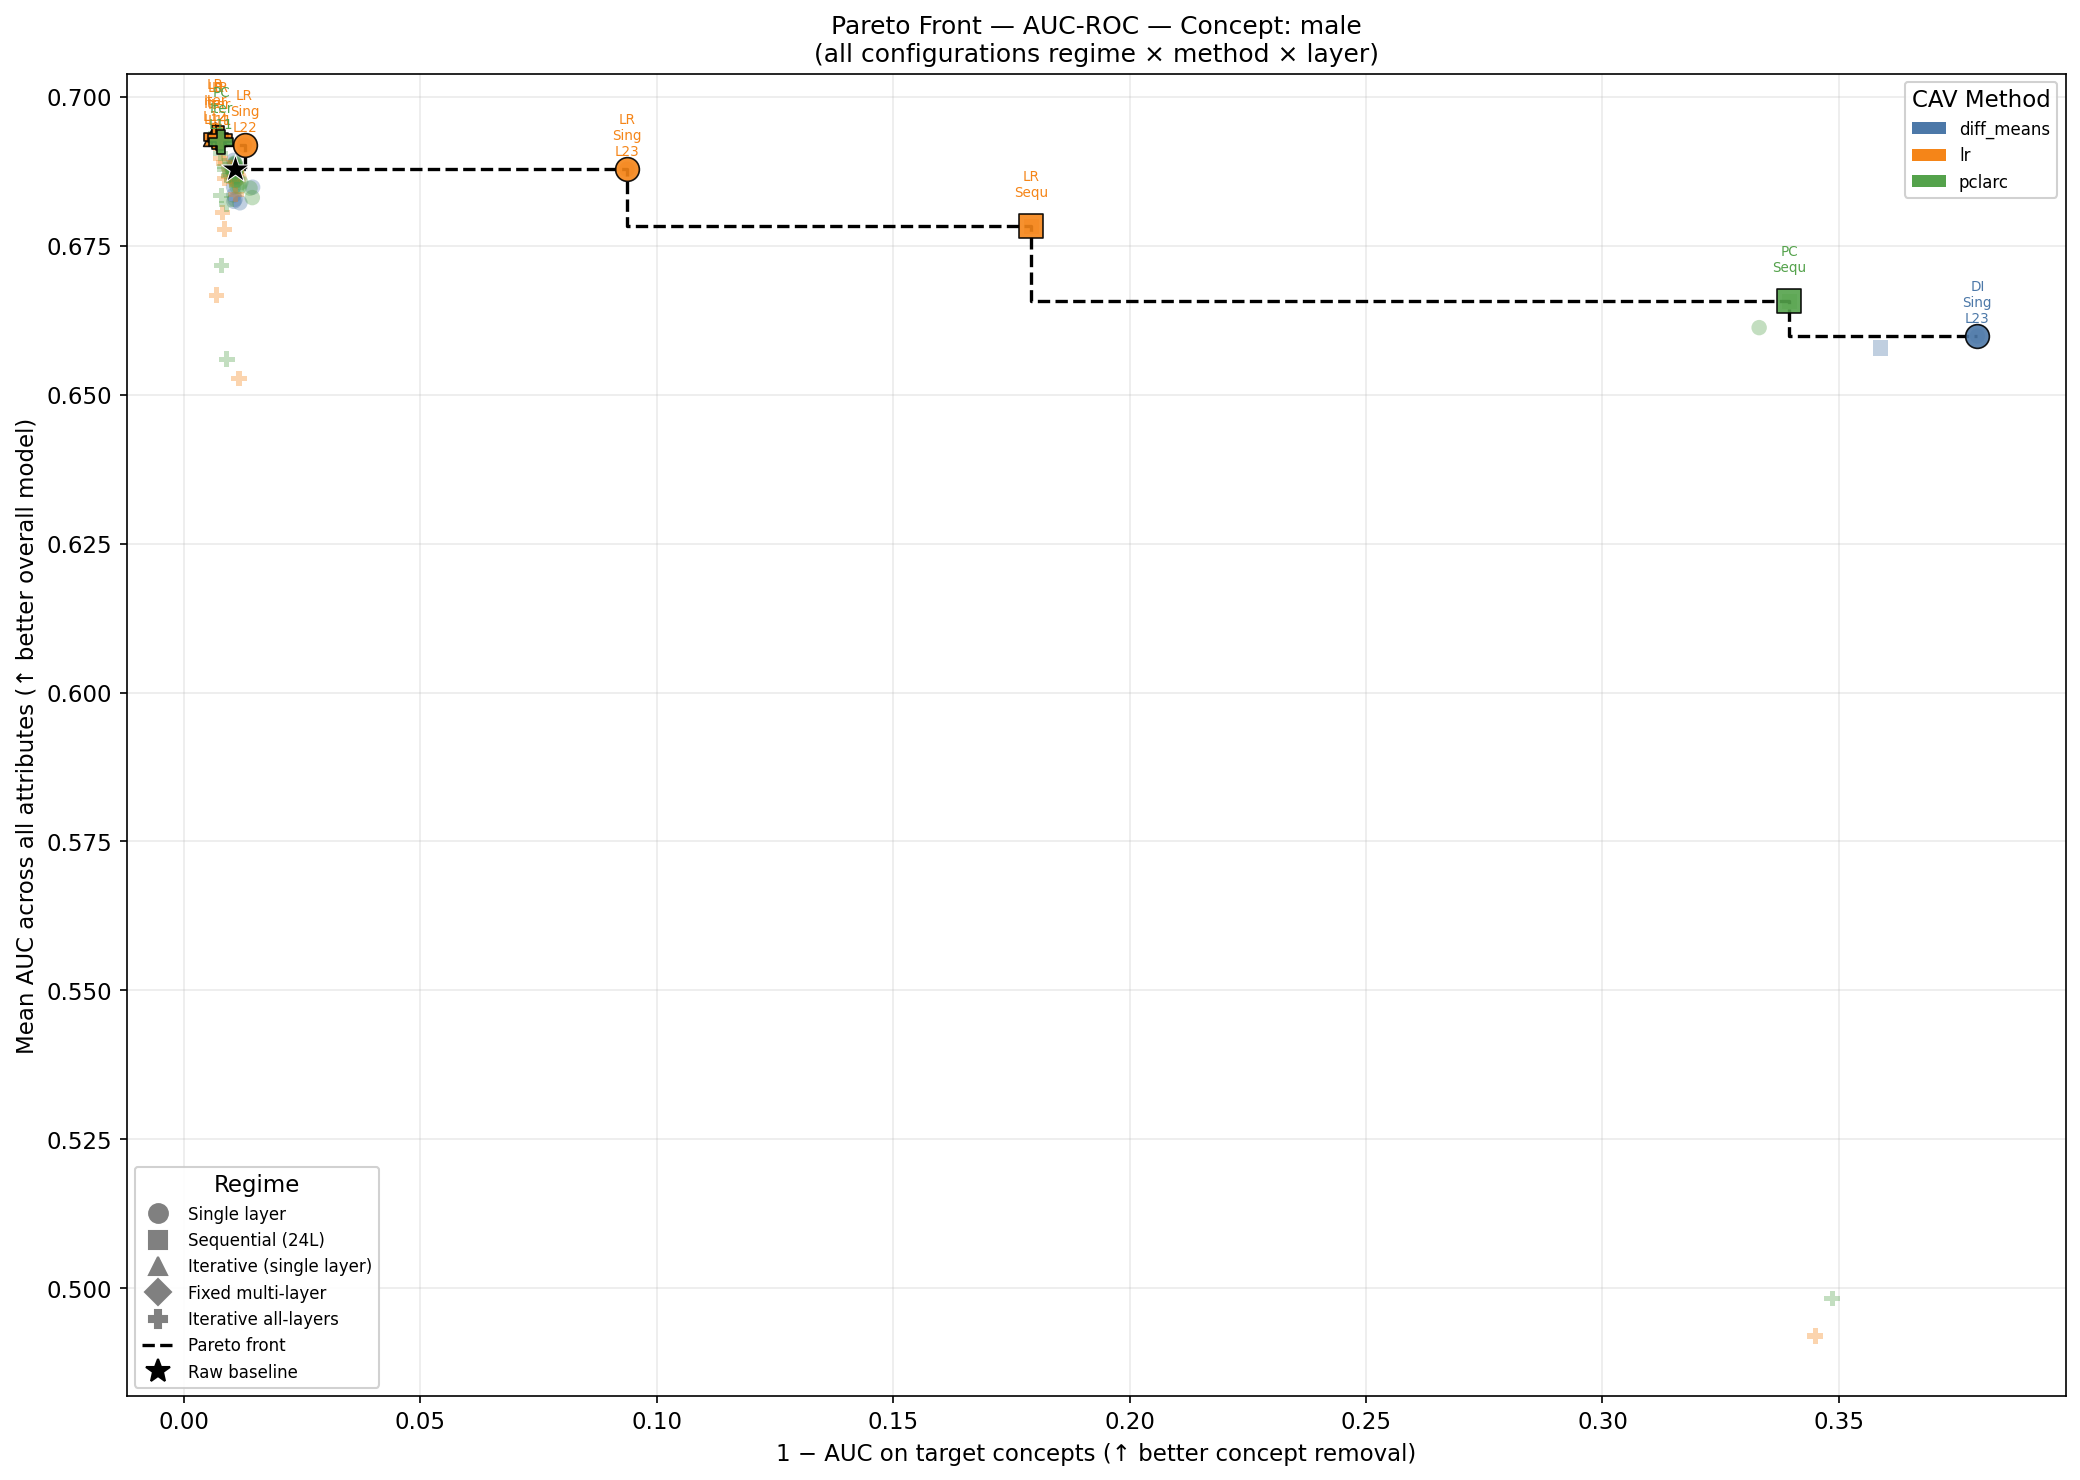

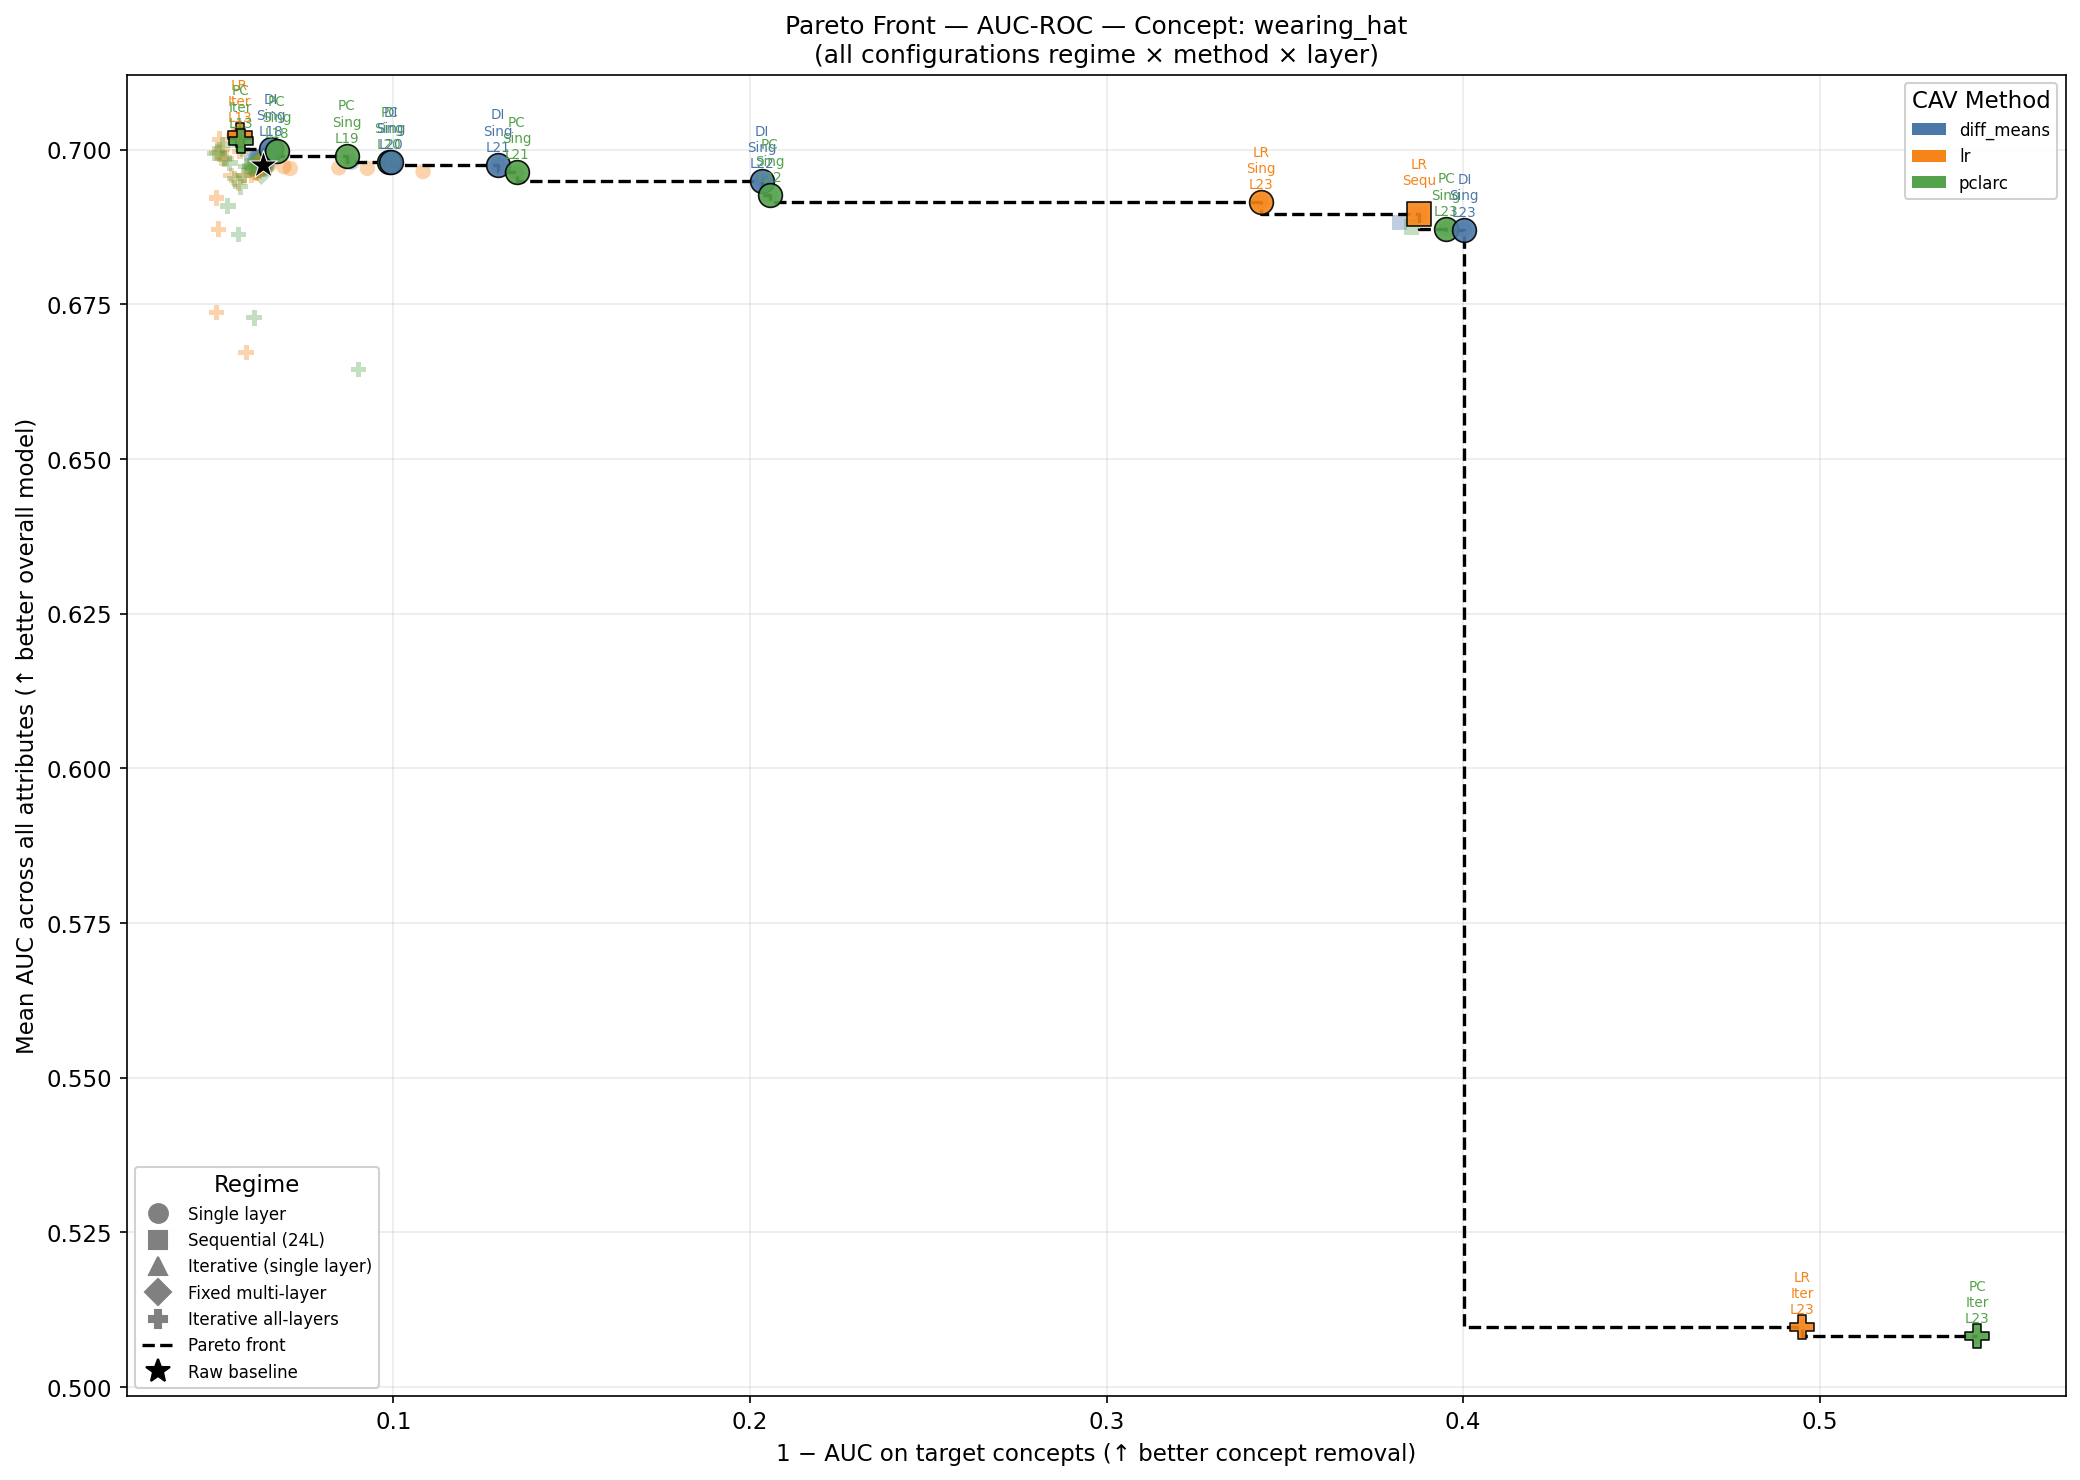

Generated 5 individual Max-Max Pareto plots for AUC.


In [13]:
# ── PARETO AUC PER CONCEPT ────────────────────────────────────────────────────

config_cols = ['regime', 'method', 'debias_layer', 'n_iterations', 'n_layers']

for concept in CONCEPTS:
    # Filter data for the specific concept
    df_concept = df_deb[df_deb['concept_file'] == concept].copy()
    
    if df_concept.empty:
        print(f"Skipping {concept} - no debiased data.")
        continue
        
    # Calculate metric on target attribute and mean across all attributes
    df_concept['is_target'] = df_concept['target_attribute'] == concept
    
    target_per_config = (
        df_concept[df_concept['is_target']]
        .groupby(config_cols, dropna=False)['auc']
        .mean()
        .reset_index()
        .rename(columns={'auc': 'metric_target'})
    )
    
    all_per_config = (
        df_concept
        .groupby(config_cols, dropna=False)['auc']
        .mean()
        .reset_index()
        .rename(columns={'auc': 'metric_all'})
    )
    
    agg_concept = target_per_config.merge(all_per_config, on=config_cols)
    agg_concept['x'] = 1 - agg_concept['metric_target']
    agg_concept['y'] = agg_concept['metric_all']
    
    # Calculate raw baseline for this specific concept
    raw_rows_concept = df[(df['regime'] == 'raw') & (df['concept_file'] == concept)]
    tgt_raw = raw_rows_concept[raw_rows_concept['target_attribute'] == concept]['auc']
    
    raw_point = None
    if not tgt_raw.empty:
        tgt_val = tgt_raw.mean()
        all_val = raw_rows_concept['auc'].mean()
        raw_point = (1 - tgt_val, all_val)
            
    fig, ax = plt.subplots(figsize=(14, 10))
    plot_pareto(agg_concept, 'AUC', ax, raw_point=raw_point)
    
    ax.set_title(
        f'Pareto Front — AUC-ROC — Concept: {concept}\n'
        f'(all configurations regime × method × layer)'
    )
    plt.tight_layout()
    
    # Clean filename (just in case concept names contain problematic characters)
    safe_concept_name = str(concept).replace('/', '_').replace(' ', '_')
    plt.savefig(OUT_DIR / f'06b_pareto_auc_{safe_concept_name}.png', dpi=150)
    plt.show()
    plt.close(fig) # Prevent memory leaks when generating multiple plots

print(f"Generated {len(CONCEPTS)} individual Max-Max Pareto plots for AUC.")

## Tabela podsumowująca

Zestawienie najlepszych konfiguracji per reżim i metoda: mediana ΔBA na target konceptach,
średnie szkody kolateralne i ogólna jakość modelu.

In [14]:
records_sum = []
for (regime, method), grp in target_only.groupby(['regime', 'method']):
    target_dba = grp['delta_ba']
    coll_grp = best[
        (best['regime'] == regime) & 
        (best['method'] == method) &
        (best['target_attribute'] != best['concept_file'])
    ]['delta_ba']

    records_sum.append({
        'Regime': REGIME_LABELS.get(regime, regime),
        'CAV Method': method,
        'Median ΔBA (target)': target_dba.median(),
        'Min ΔBA (target)': target_dba.min(),
        'Mean collateral ΔBA': coll_grp.mean(),
        '# damaged attributes': (coll_grp < -COLLATERAL_THRESHOLD).sum(),
        'n concepts': grp['concept_file'].nunique(),
    })

df_summary = pd.DataFrame(records_sum).sort_values('Median ΔBA (target)')
df_summary = df_summary.round(4)
df_summary.to_csv(OUT_DIR / 'summary_table.csv', index=False)

print('=== SUMMARY TABLE ===')
print(df_summary.to_string(index=False))
print(f'\nSaved to {OUT_DIR}/summary_table.csv')

=== SUMMARY TABLE ===
                  Regime CAV Method  Median ΔBA (target)  Min ΔBA (target)  Mean collateral ΔBA  # damaged attributes  n concepts
    Iterative all-layers         lr              -0.3477           -0.4453              -0.1382                   149           5
            Single layer diff_means              -0.3398           -0.4727              -0.0096                    49           5
        Sequential (24L)         lr              -0.2734           -0.3906              -0.0053                    48           5
        Sequential (24L) diff_means              -0.2617           -0.4453              -0.0115                    65           5
    Iterative all-layers     pclarc              -0.2578           -0.4805              -0.1362                   150           5
            Single layer         lr              -0.2578           -0.3711              -0.0012                    23           5
            Single layer     pclarc              -0.2305           -